In [1]:
import warnings
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.gen_plots import sgt_excel_to_dataframe, sgt_scaling_plot

warnings.filterwarnings("ignore", category=RuntimeWarning)
# Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [2]:
# Read the Excel files and save in one DataFrame
allowed_ext = ".xlsx"
excel_dir_path = "n_200/"
pdf_file = "n_200/scaling_results-gamma.pdf"
plt_figs = []

all_sheets = sgt_excel_to_dataframe(excel_dir_path, allowed_ext)
print(all_sheets.keys())

dict_keys(['Nodes-Edges', 'Nodes-Edges(Fit)', 'Nodes-Degree', 'Nodes-Degree(Fit)', 'Nodes-Diameter', 'Nodes-Diameter(Fit)', 'Nodes-Density', 'Nodes-Density(Fit)', 'Nodes-ASC', 'Nodes-ASC(Fit)', 'Nodes-ACC', 'Nodes-ACC(Fit)', 'Nodes-BC', 'Nodes-BC(Fit)', 'Nodes-EC', 'Nodes-EC(Fit)', 'Nodes-CC', 'Nodes-CC(Fit)', 'Nodes-GE', 'Nodes-GE(Fit)'])


In [3]:
# Filter the relevant materials and parameters
materials = ['BSE 017', 'BSE 011', 'BSE 024', 'BSE 025']
material_names = ['PAN/CGO', 'Carb. PAN', 'PAN', 'Carb. PAN/CGO']
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']

material_labels = {key: name for (name, key) in zip(material_names, materials)}

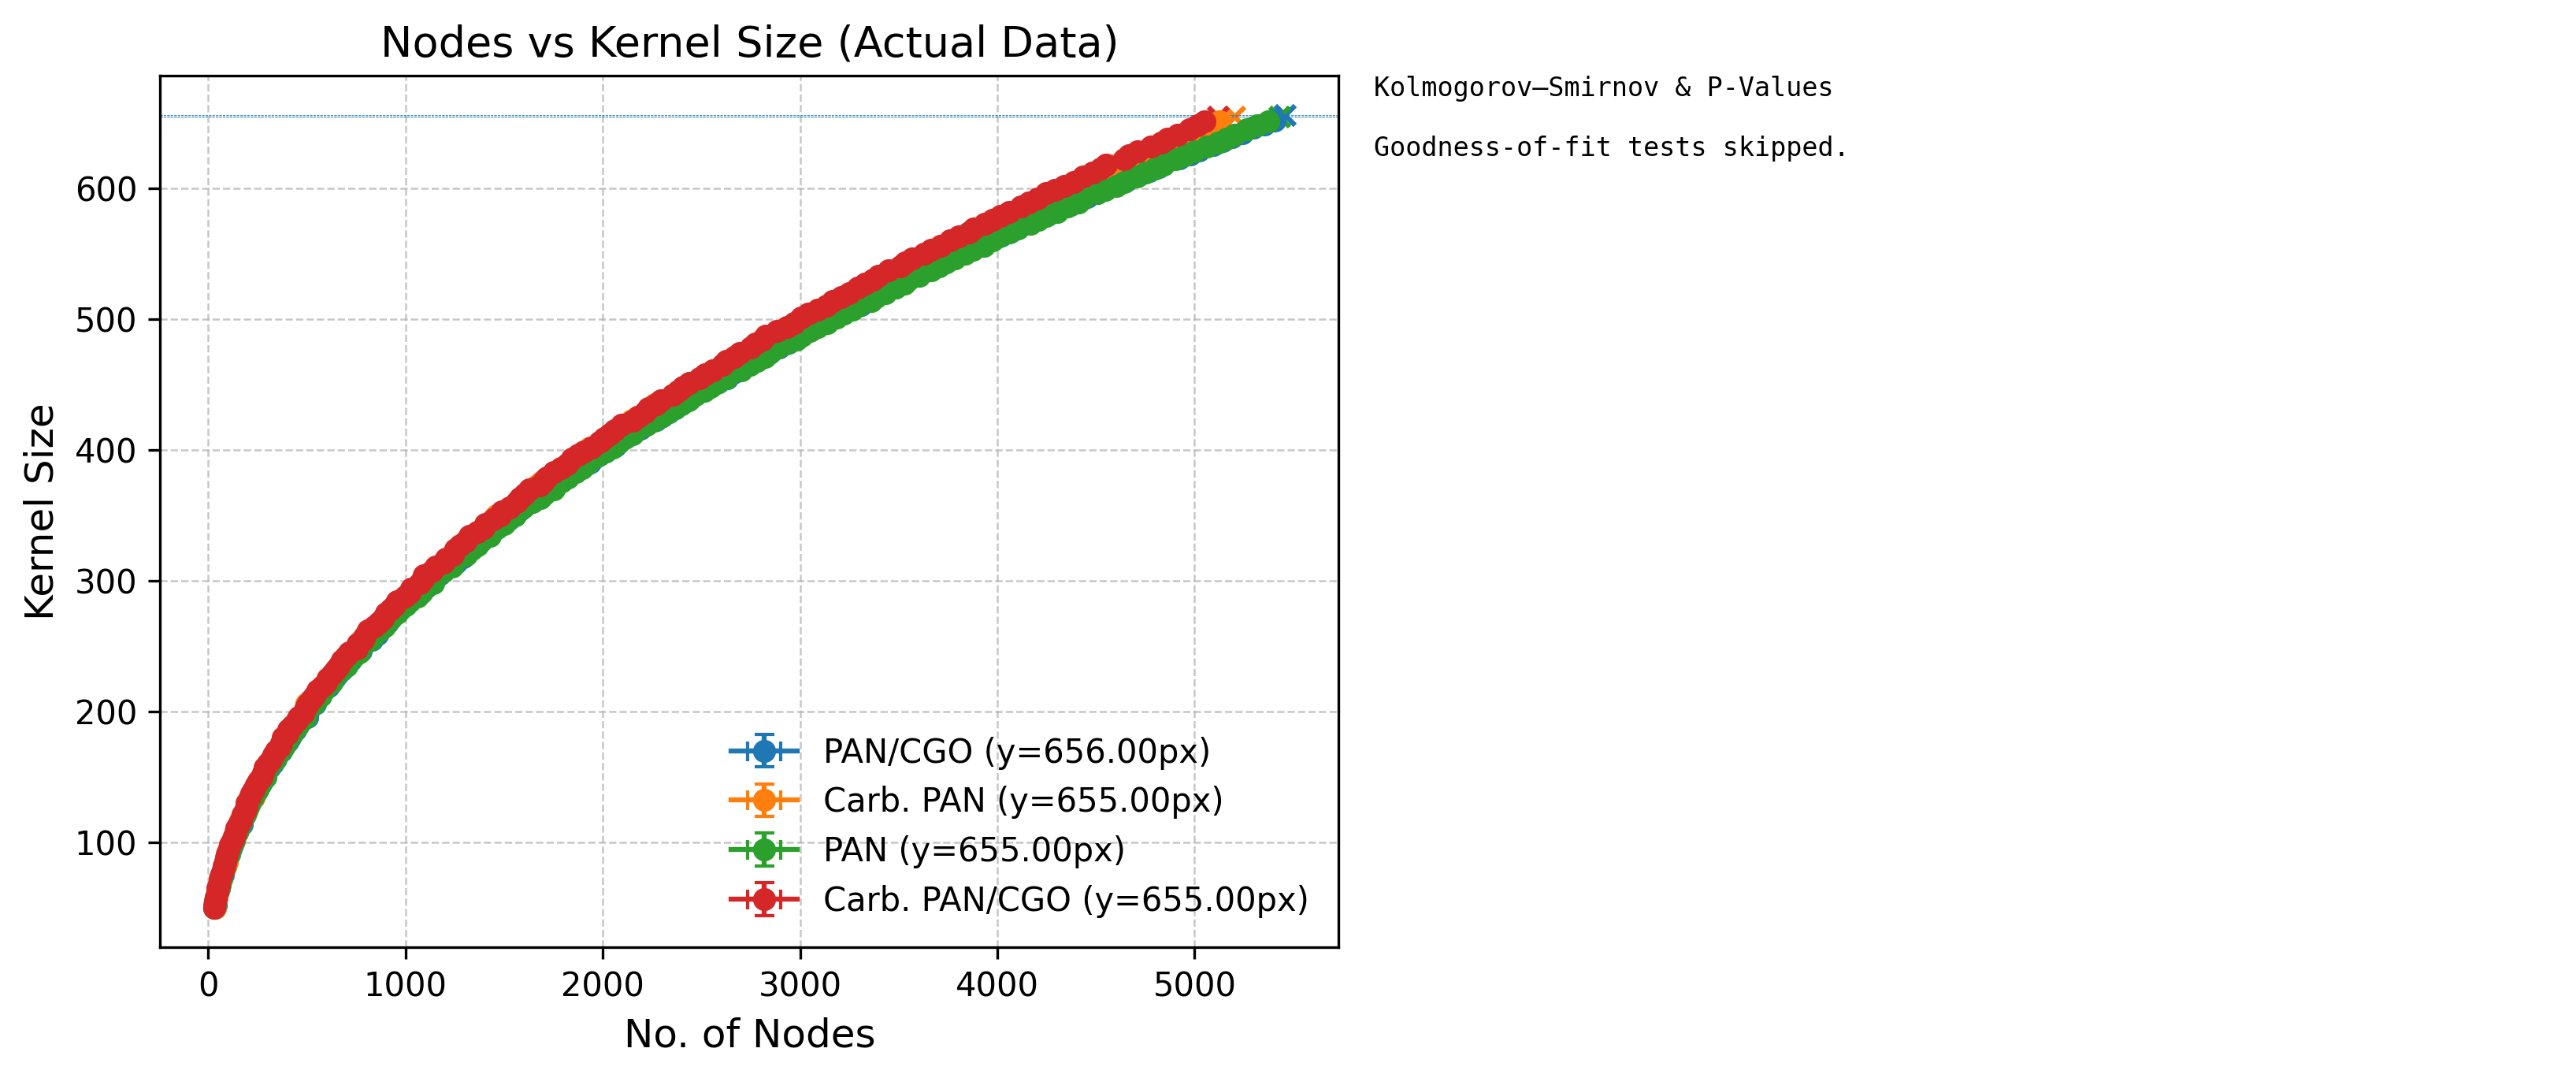

In [6]:
"""
Kernel Size vs Nodes
"""
df_edges = all_sheets['Nodes-Edges']
plt_fig = sgt_scaling_plot("Kernel Size", df_edges, material_labels, skip_test=True)
plt_figs.append(plt_fig)

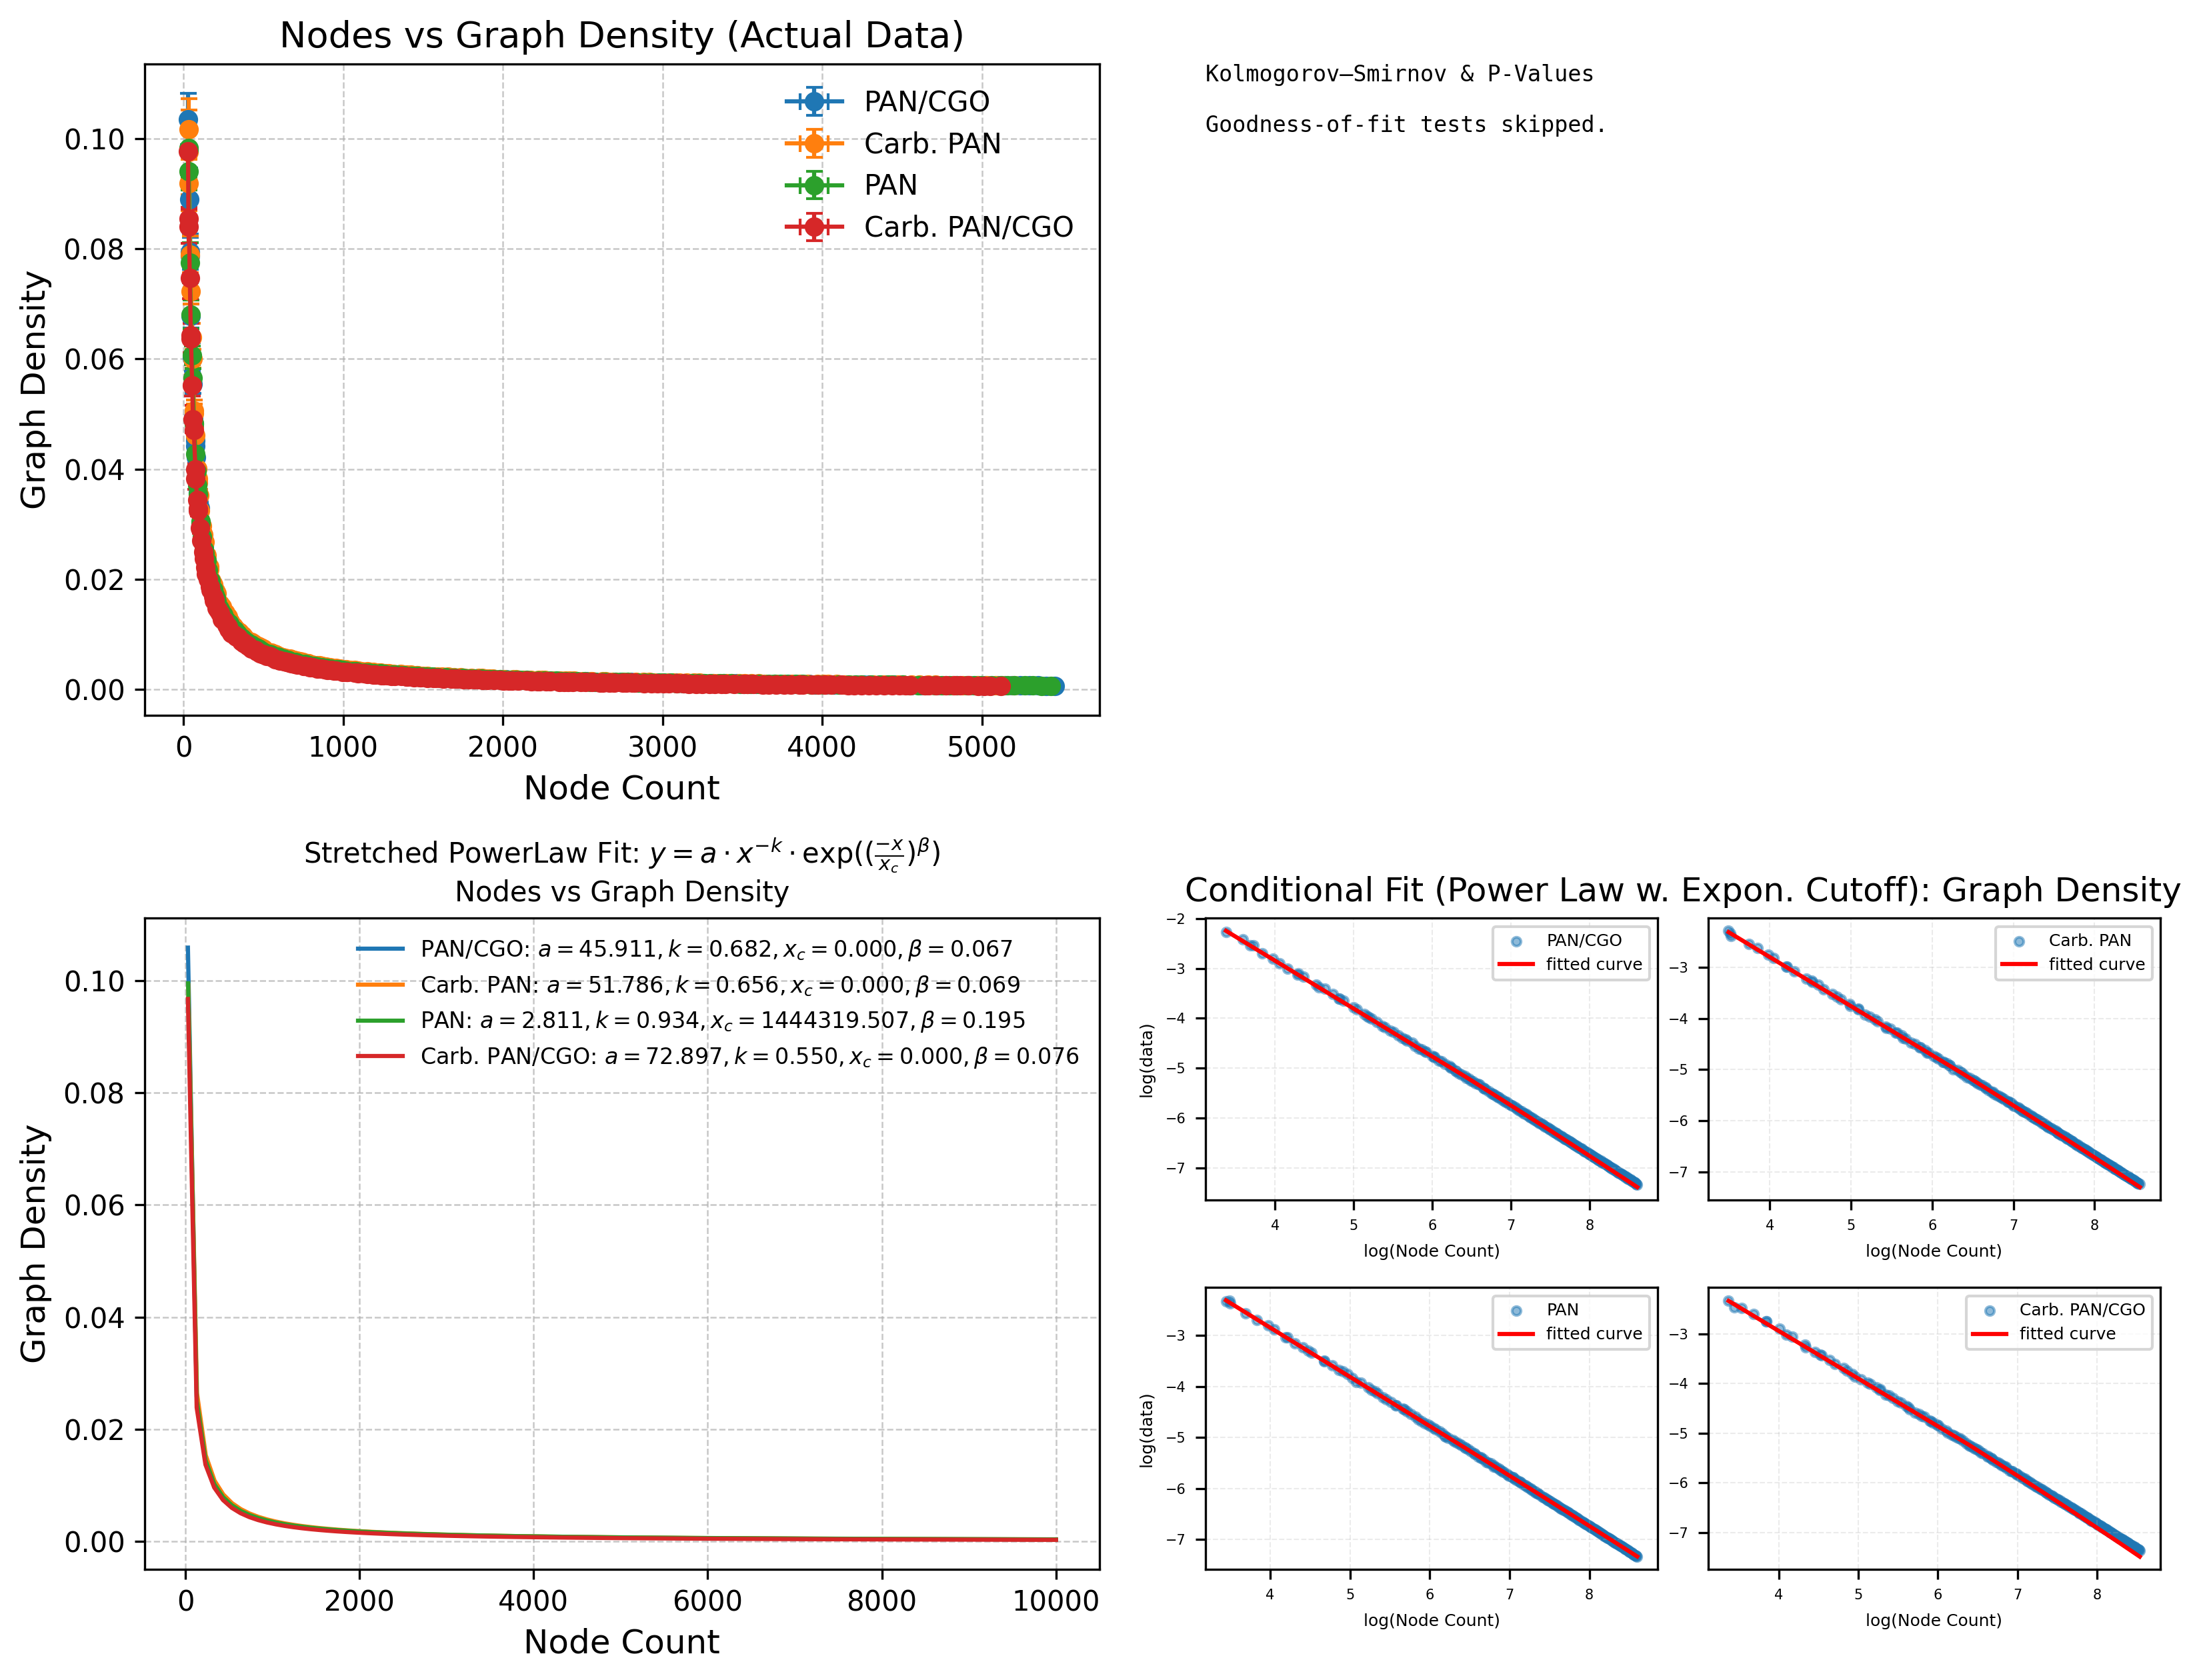

In [8]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-Density']
plt_fig = sgt_scaling_plot("Graph Density", df_dens, material_labels, skip_test=True, fit_func="powerlaw-ec", qq_plot=False)
plt_figs.append(plt_fig)

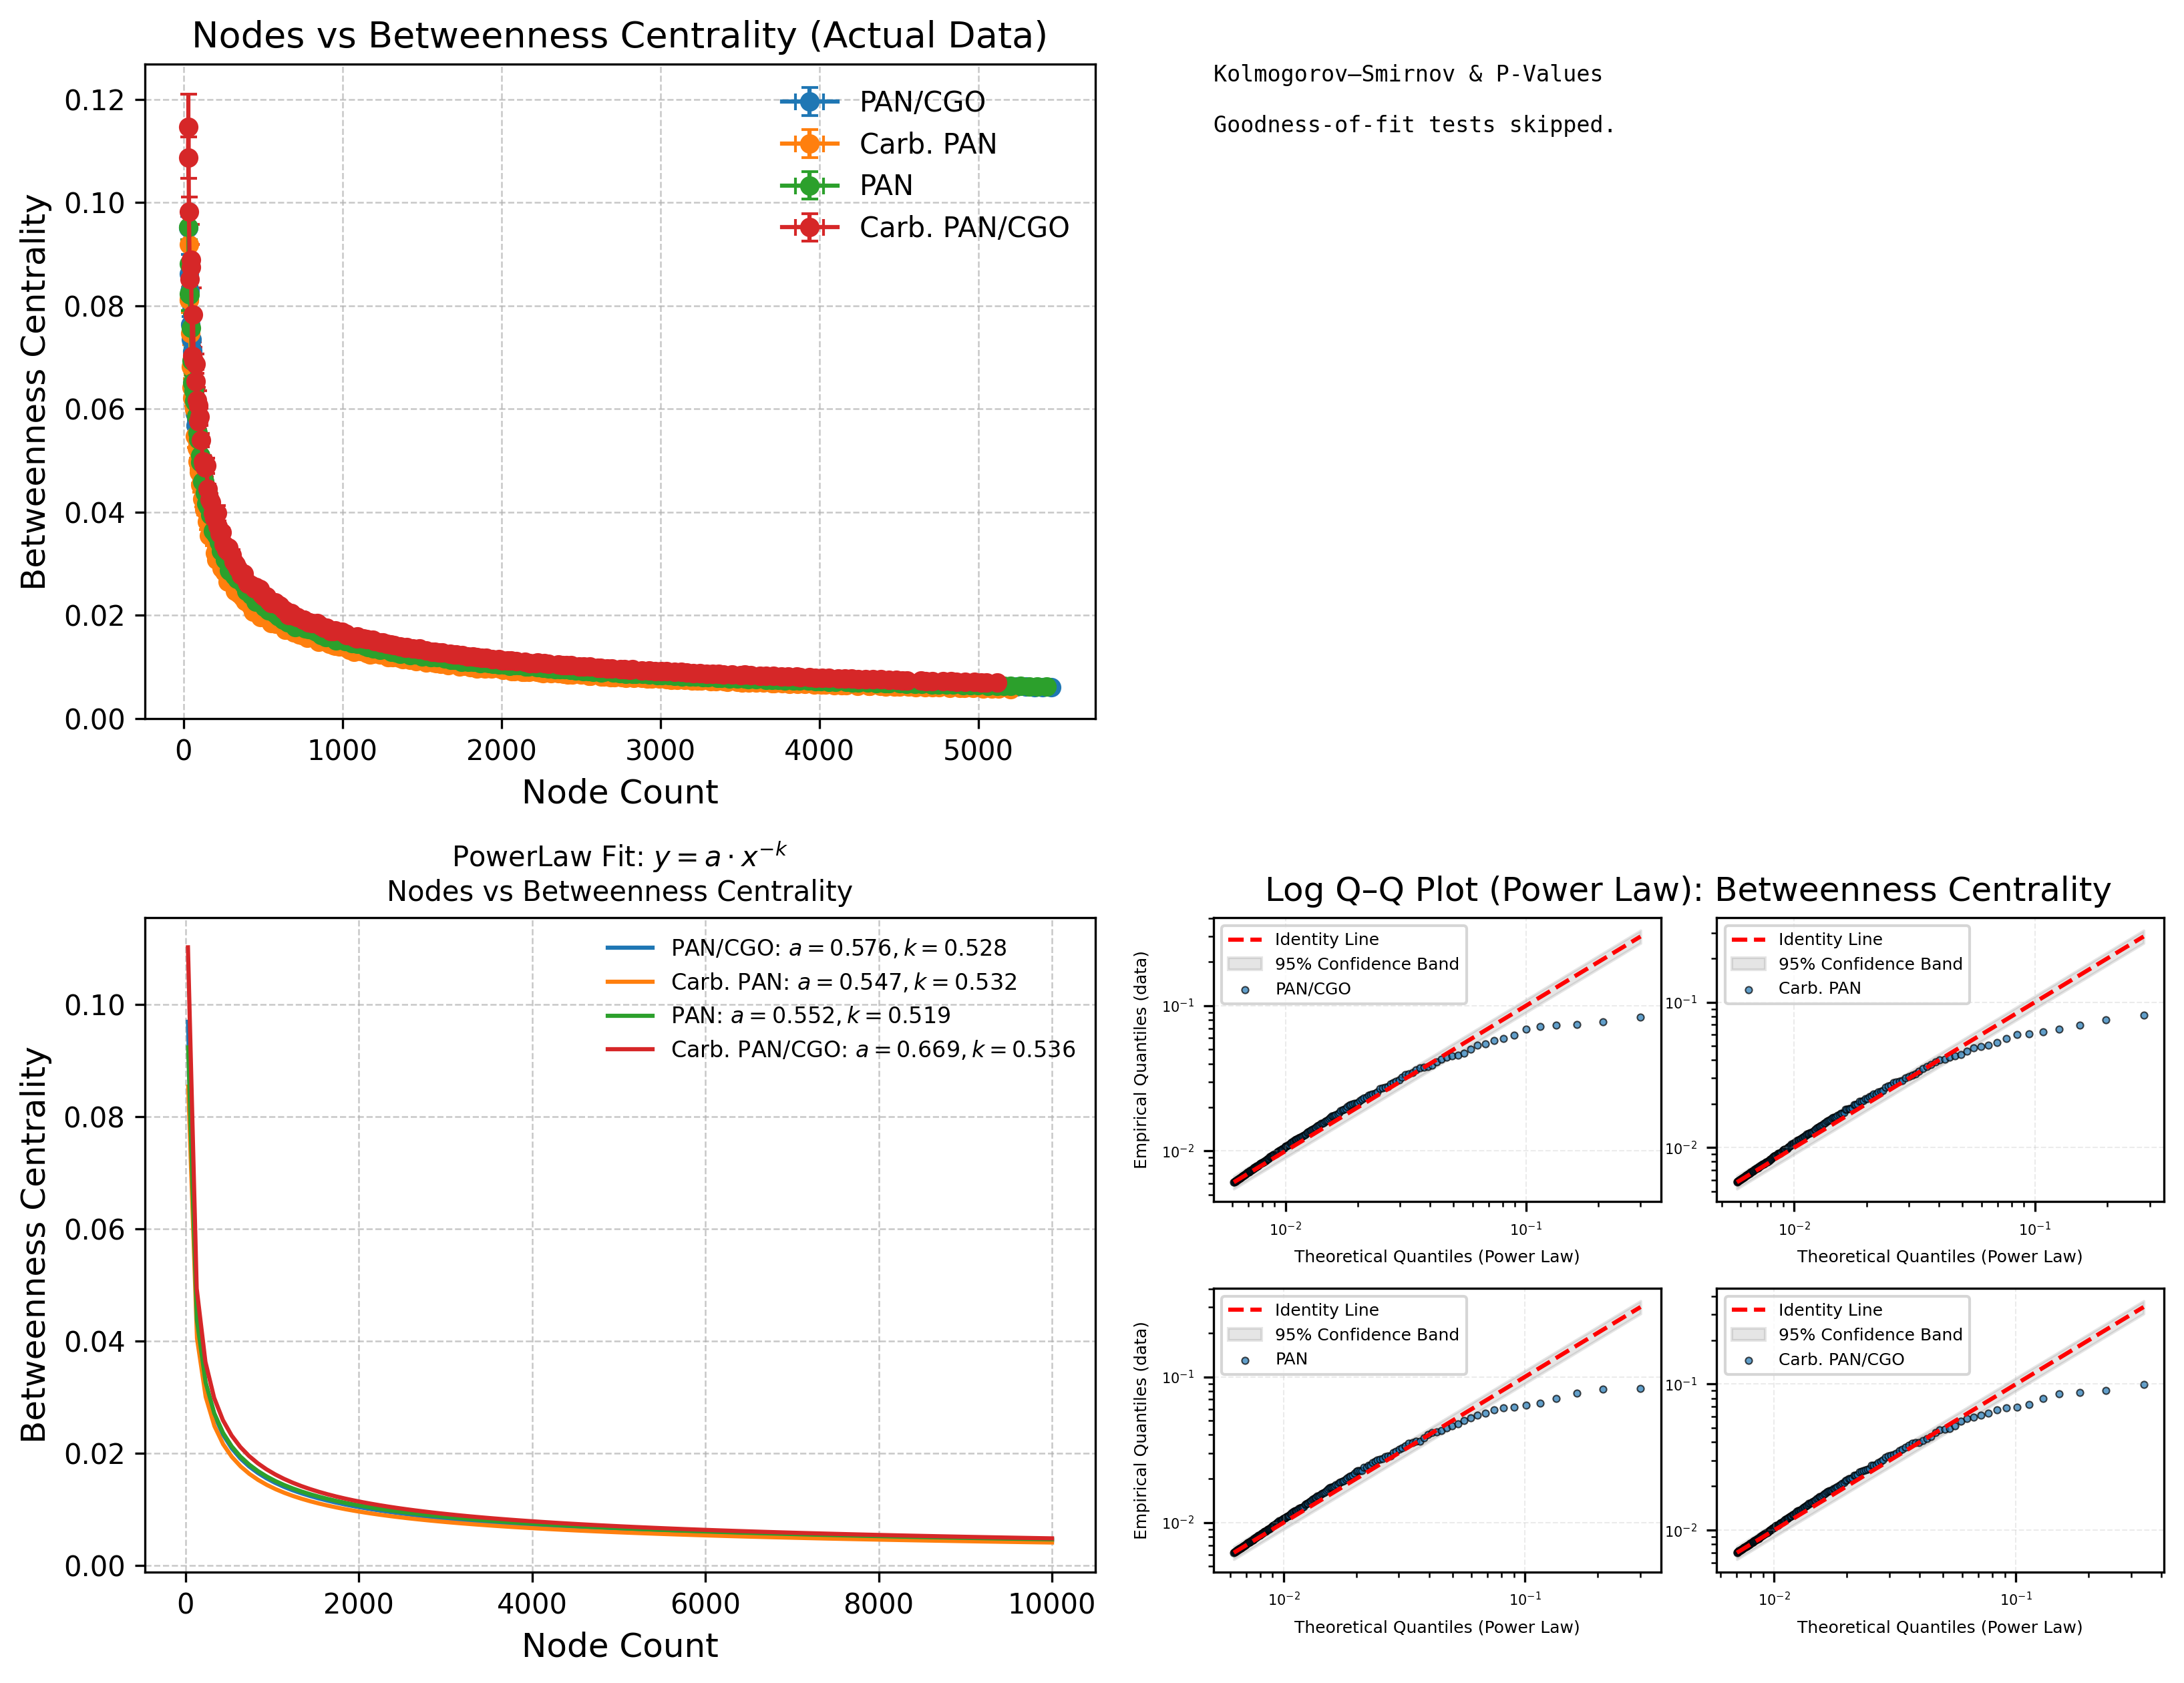

In [9]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-BC']
plt_fig = sgt_scaling_plot("Betweenness Centrality", df_bet, material_labels, skip_test=True, fit_func="powerlaw")
plt_figs.append(plt_fig)

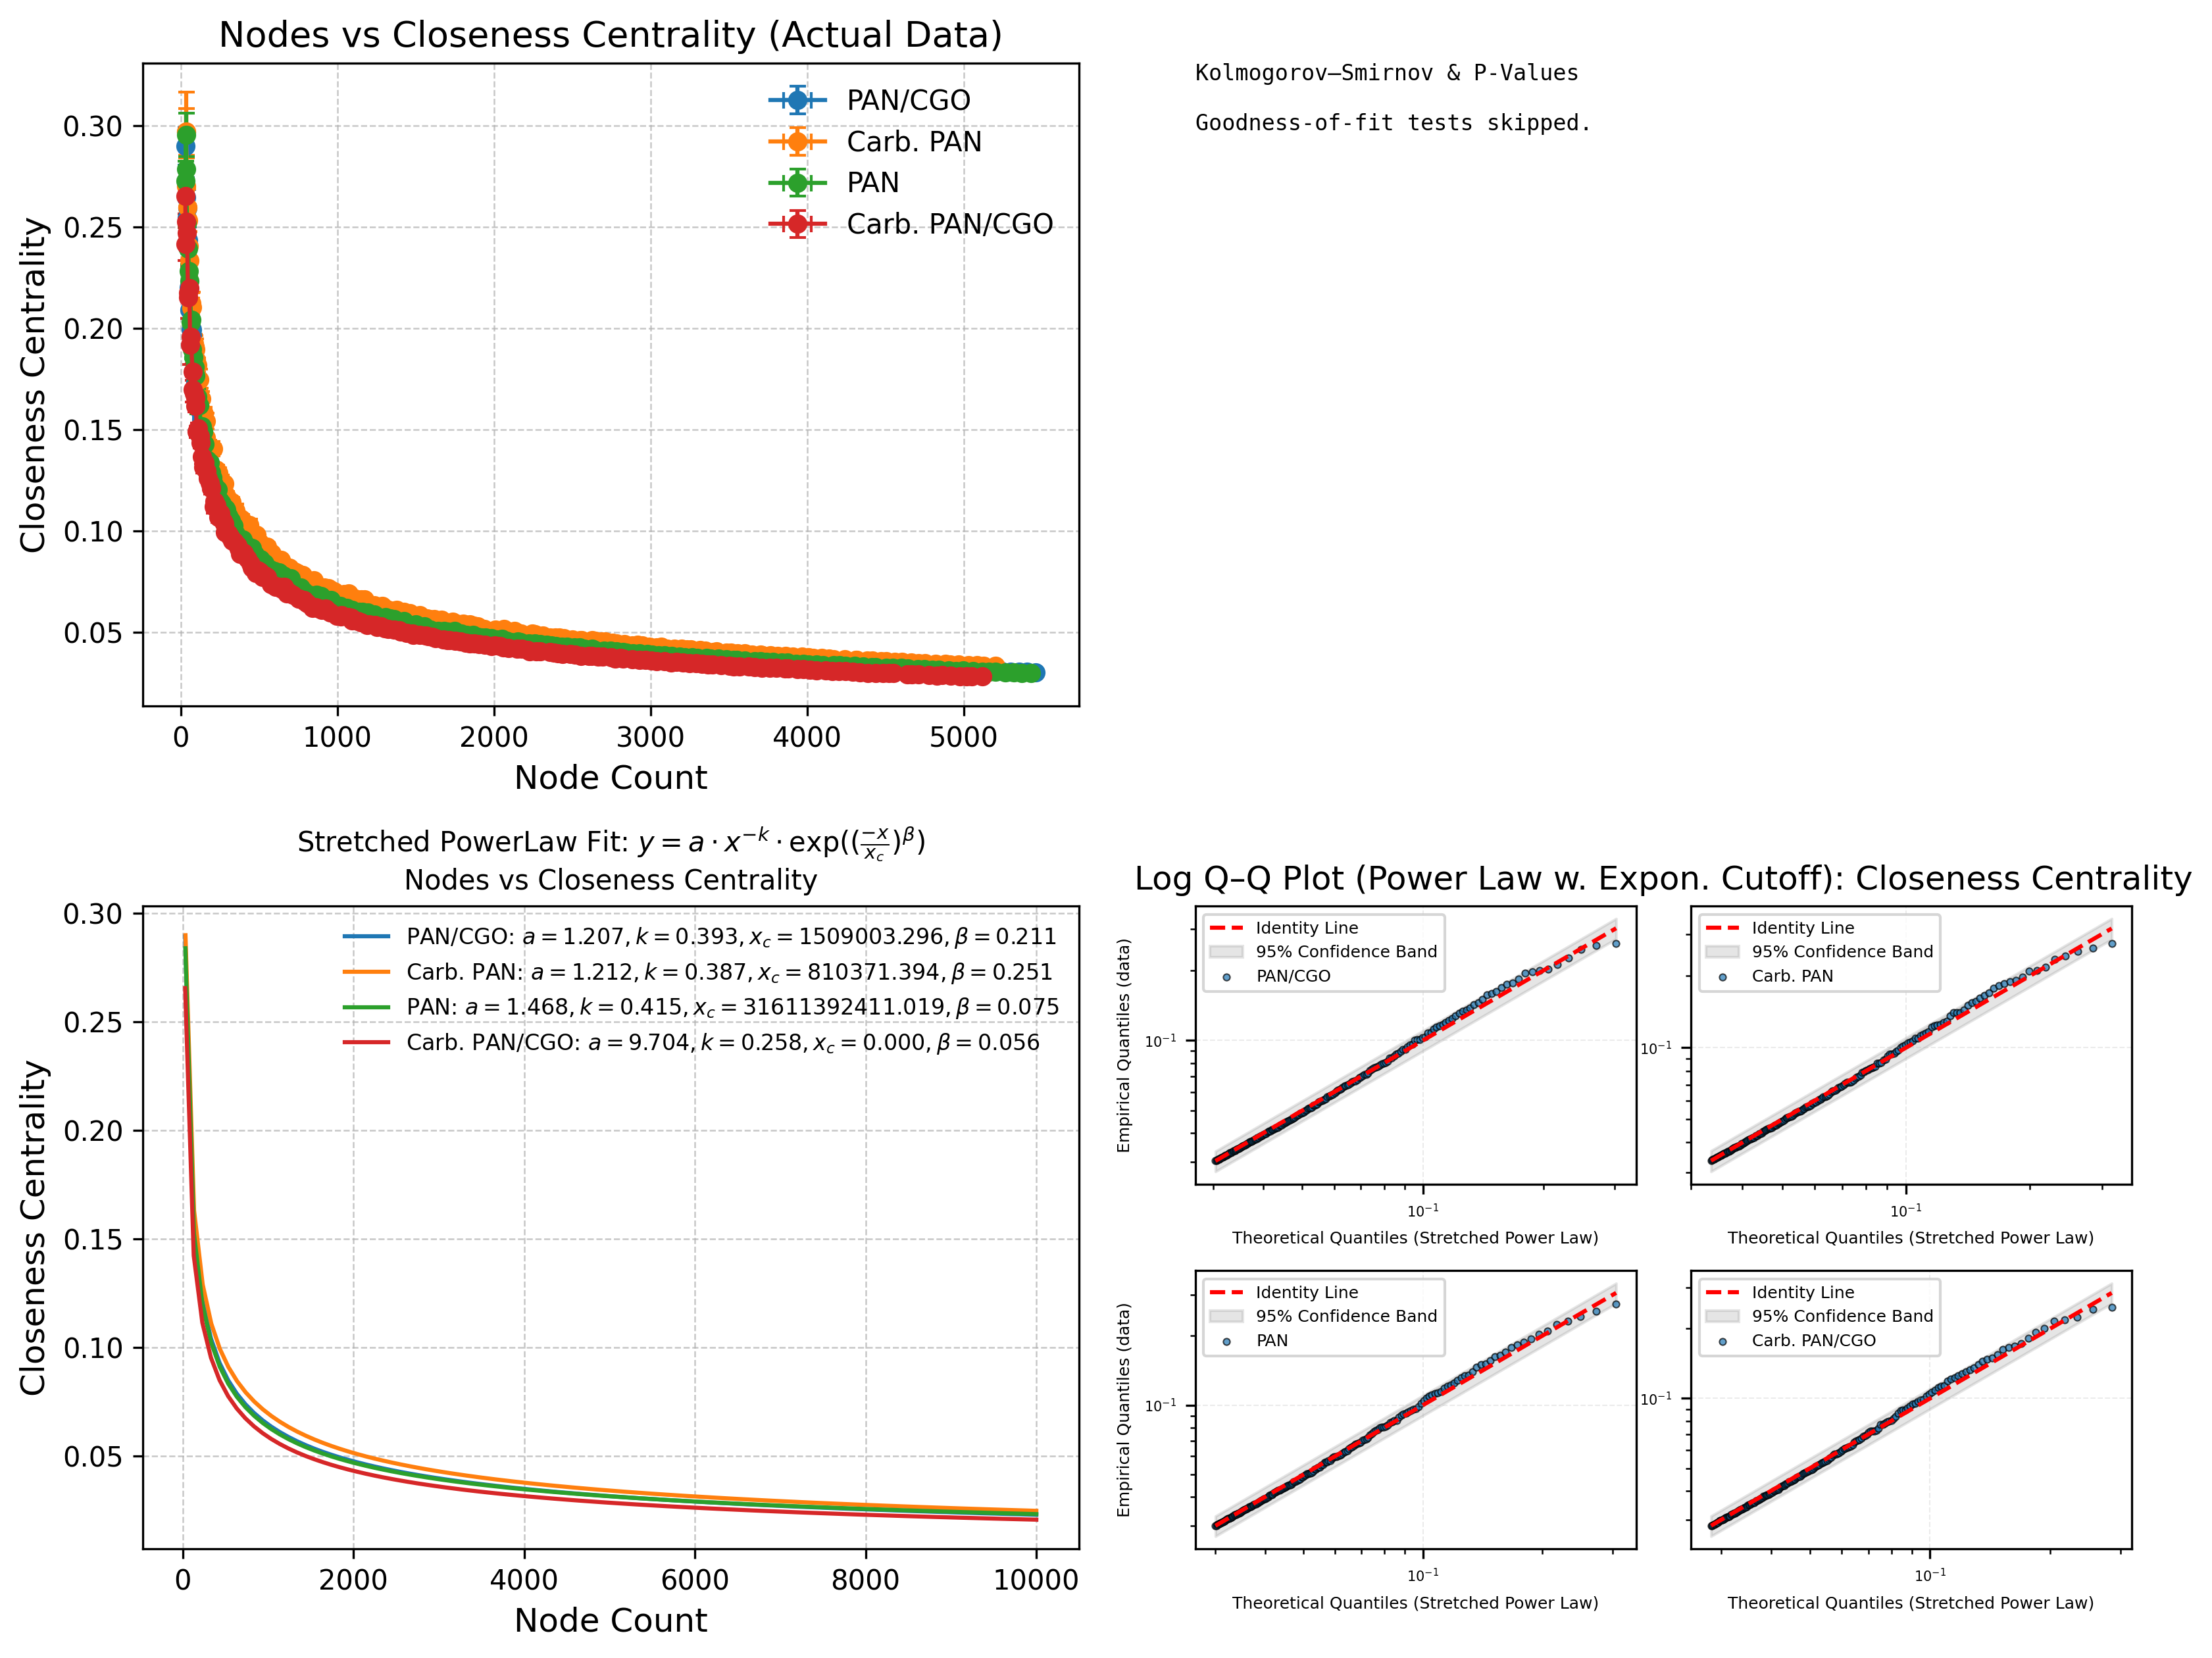

In [10]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-CC']
plt_fig = sgt_scaling_plot("Closeness Centrality", df_clo, material_labels, skip_test=True, fit_func="powerlaw-ec")
plt_figs.append(plt_fig)

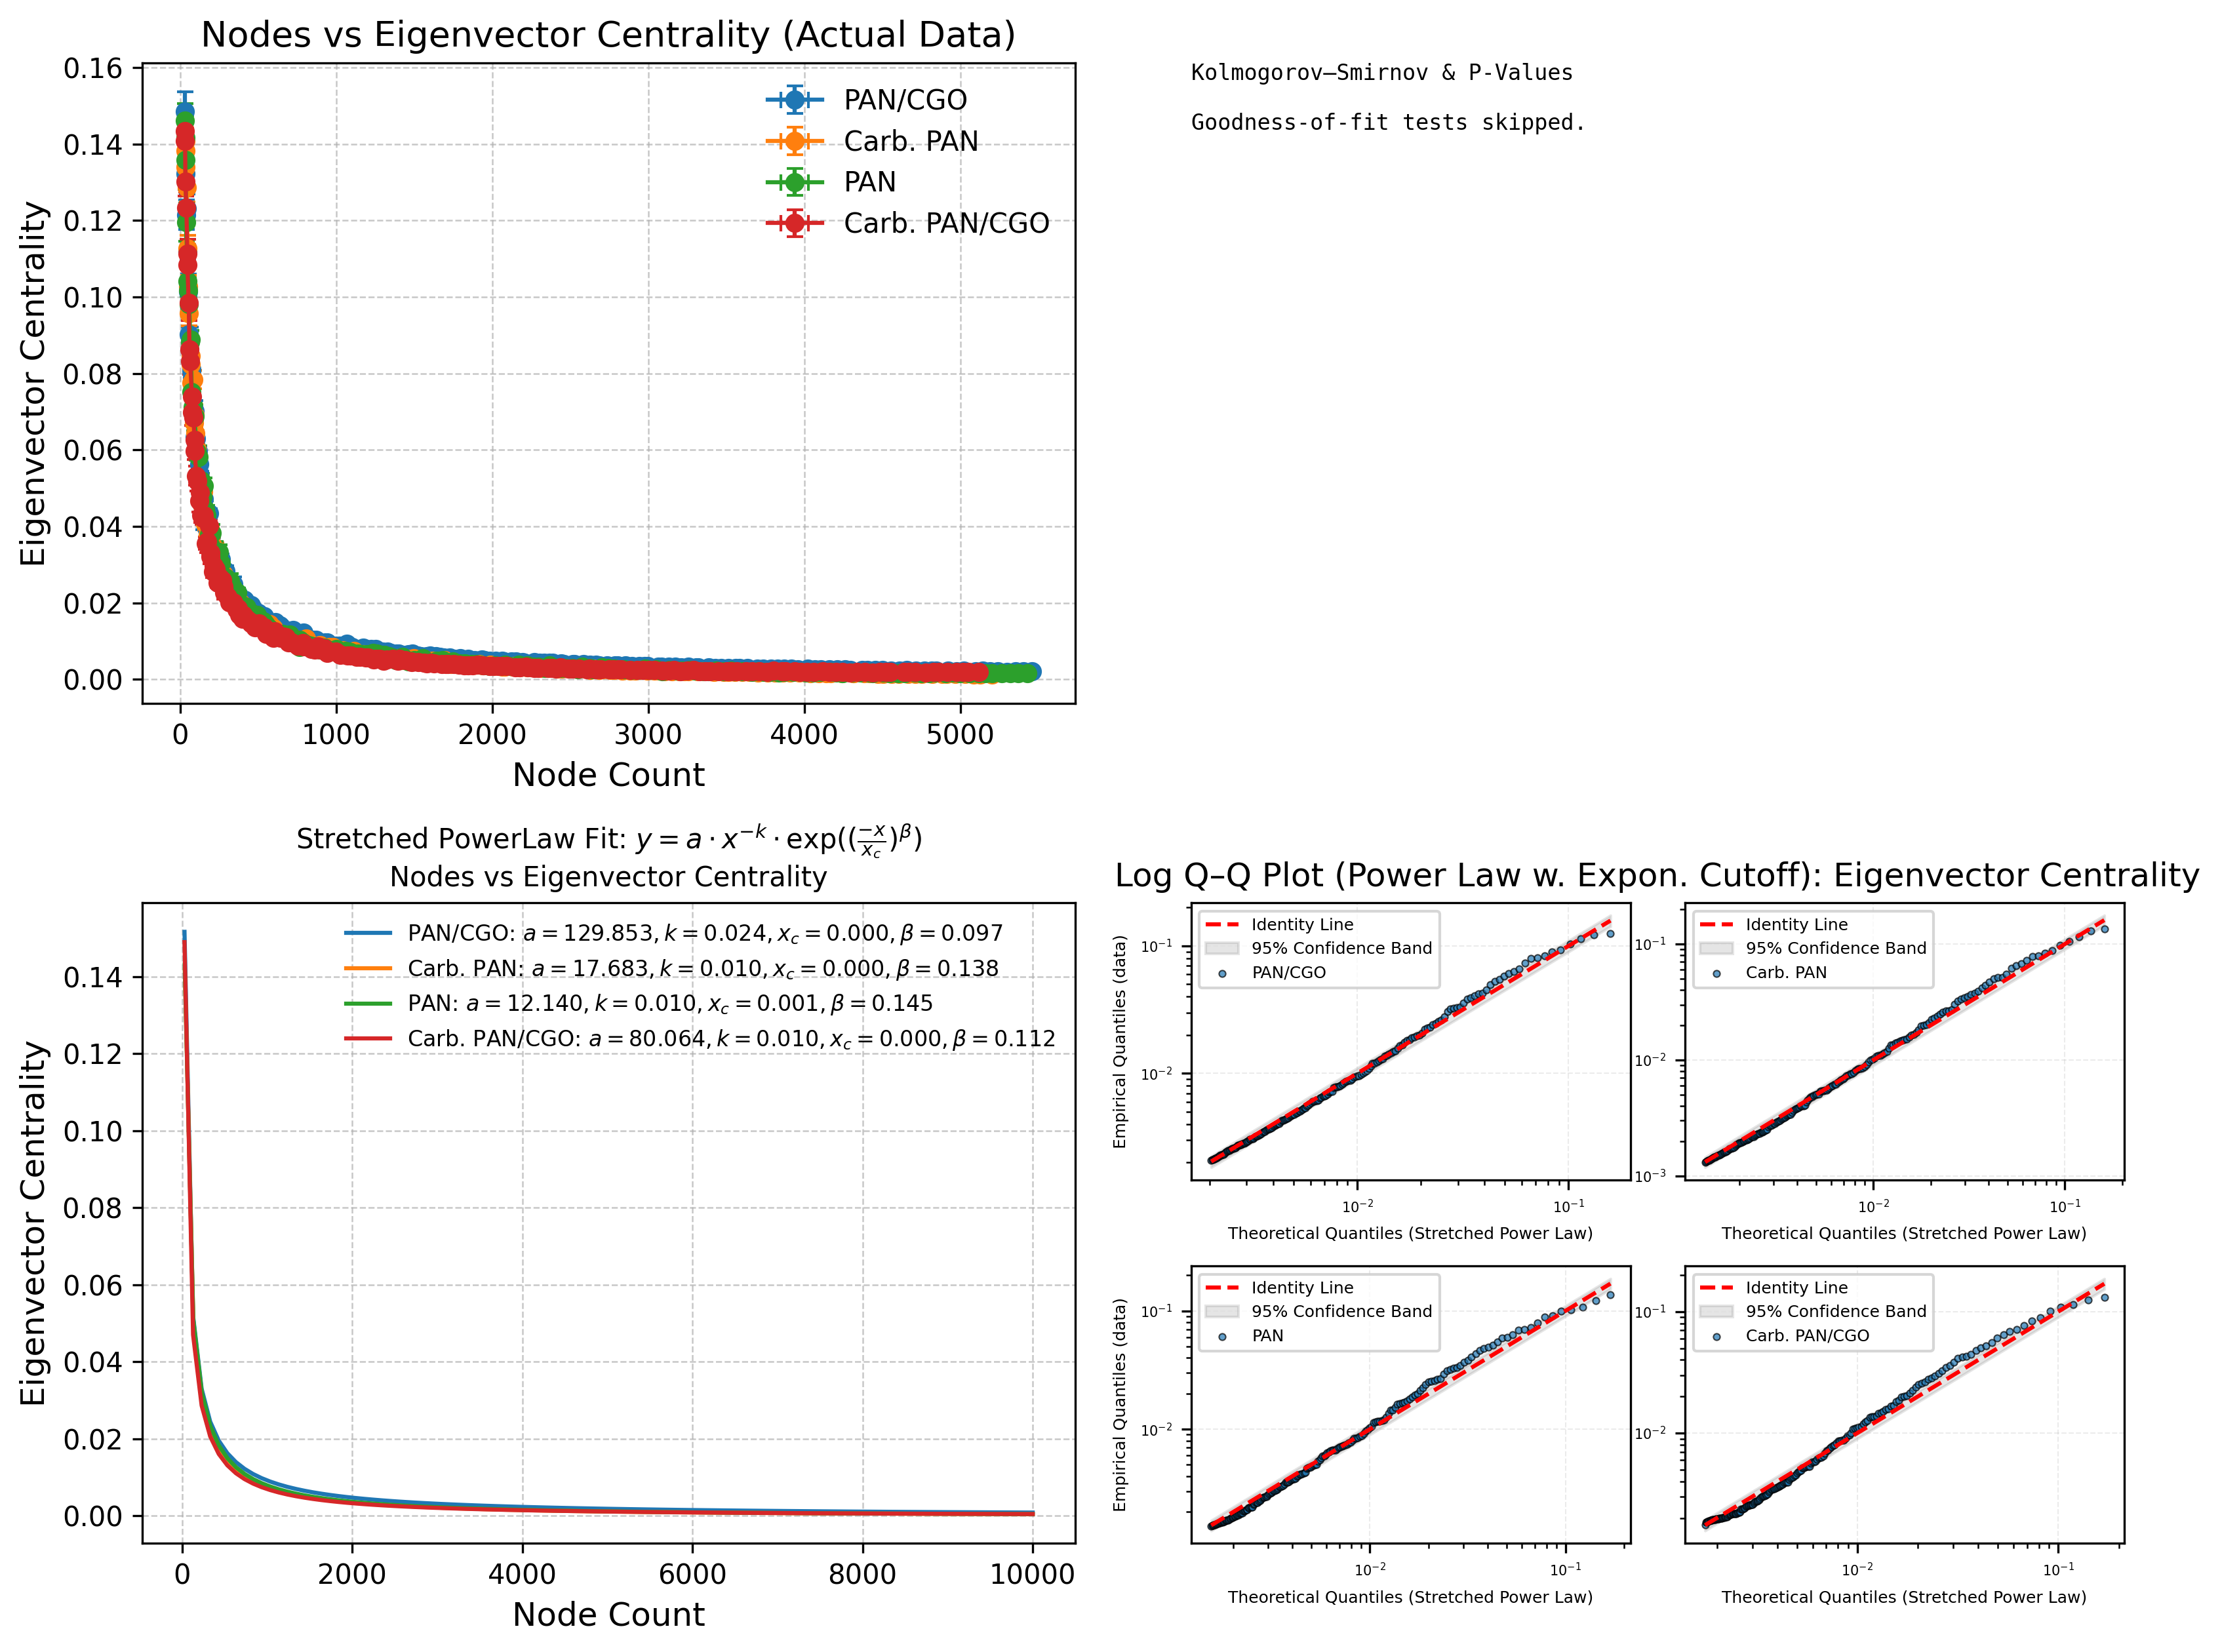

In [11]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-EC']
plt_fig = sgt_scaling_plot("Eigenvector Centrality", df_eig, material_labels, skip_test=True, fit_func="powerlaw-ec")
plt_figs.append(plt_fig)

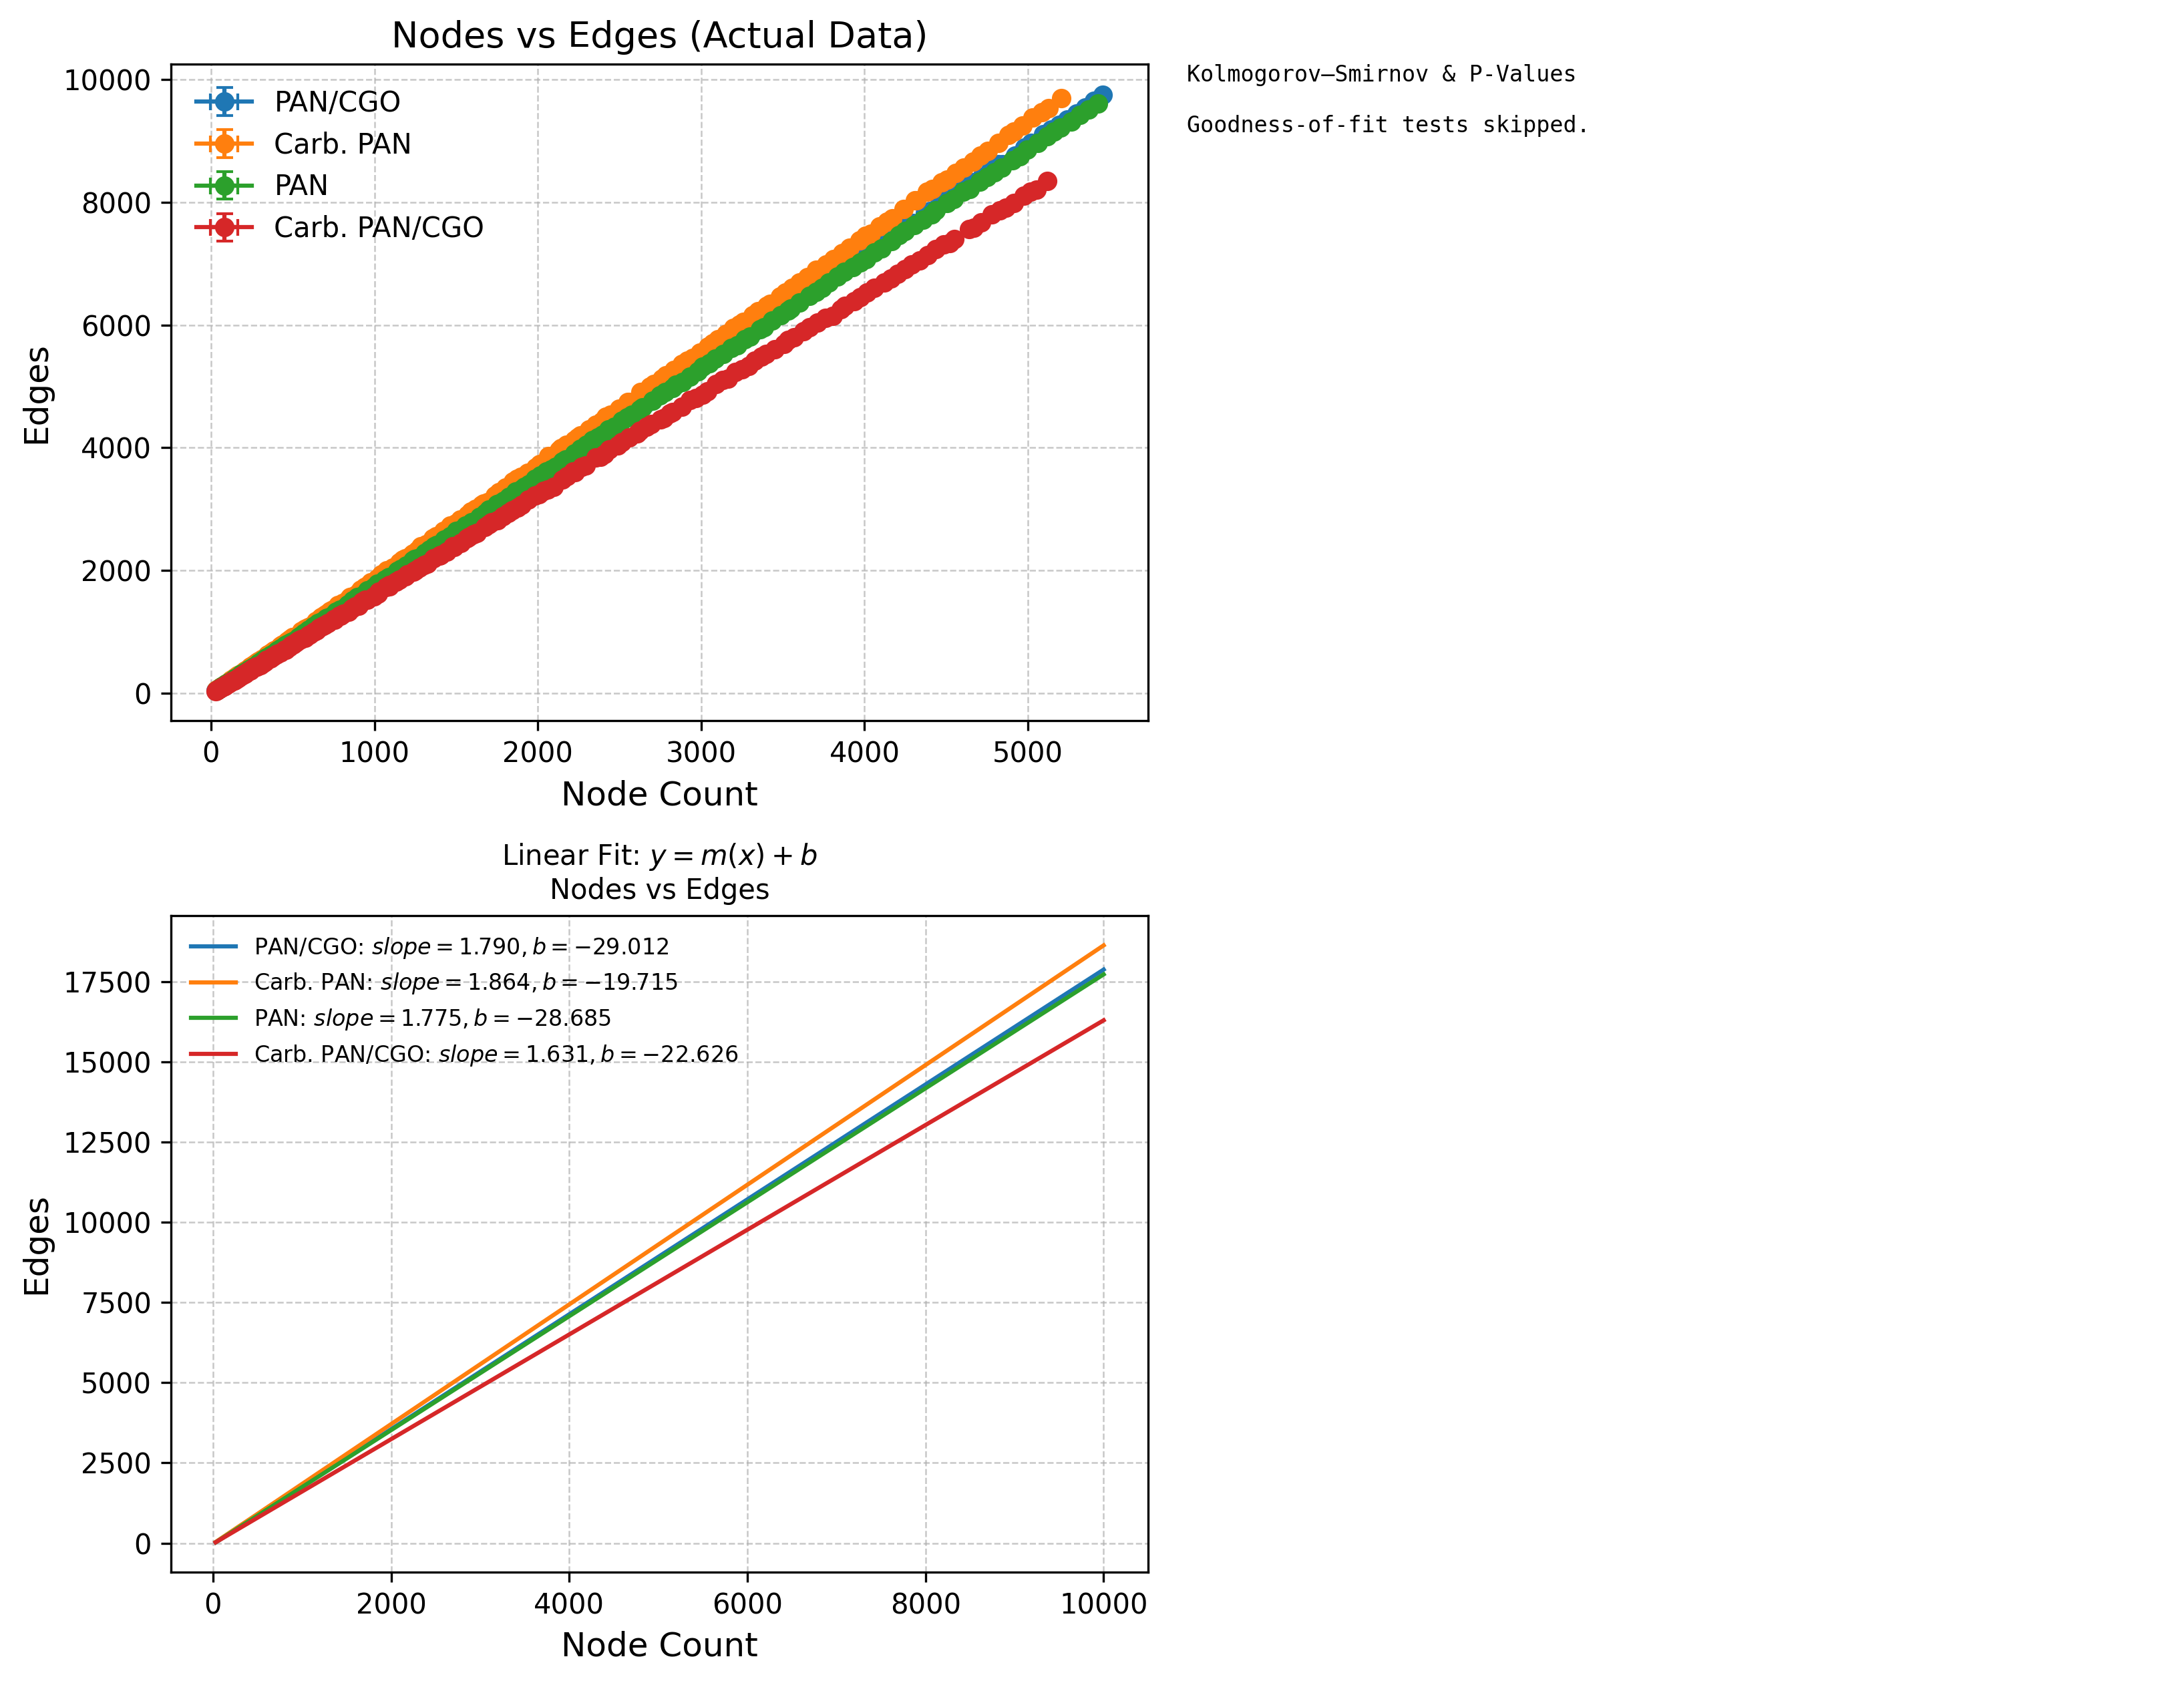

In [12]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']
plt_fig = sgt_scaling_plot("Edges", df_edges, material_labels, skip_test=True, fit_func="linear")
plt_figs.append(plt_fig)

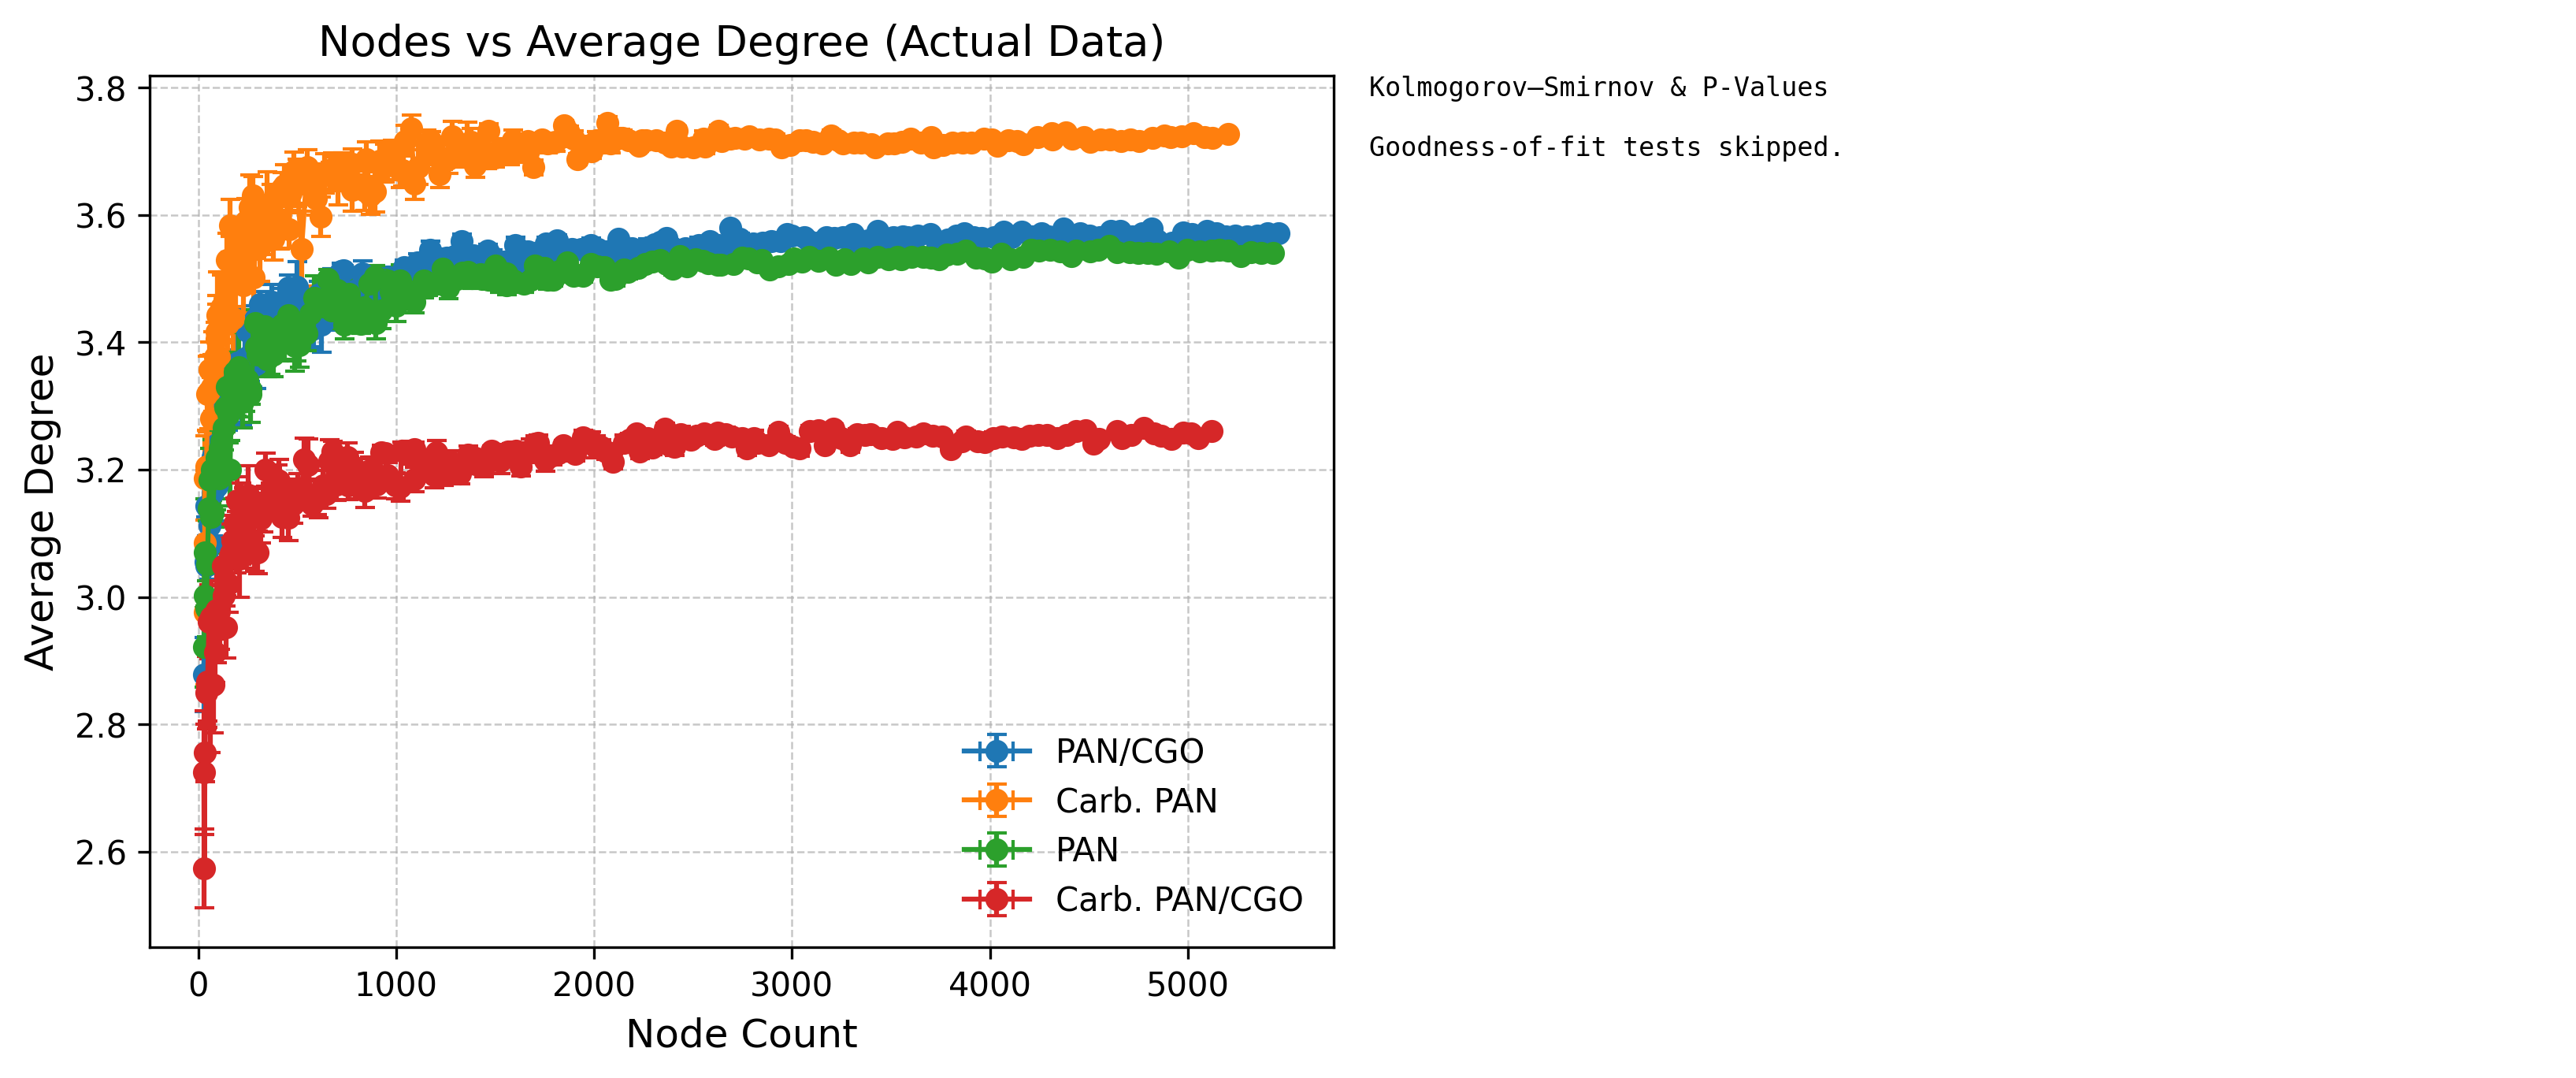

In [13]:
"""
Average Degree
"""
df_deg = all_sheets['Nodes-Degree']
plt_fig = sgt_scaling_plot("Average Degree", df_deg, material_labels, skip_test=True)
plt_figs.append(plt_fig)

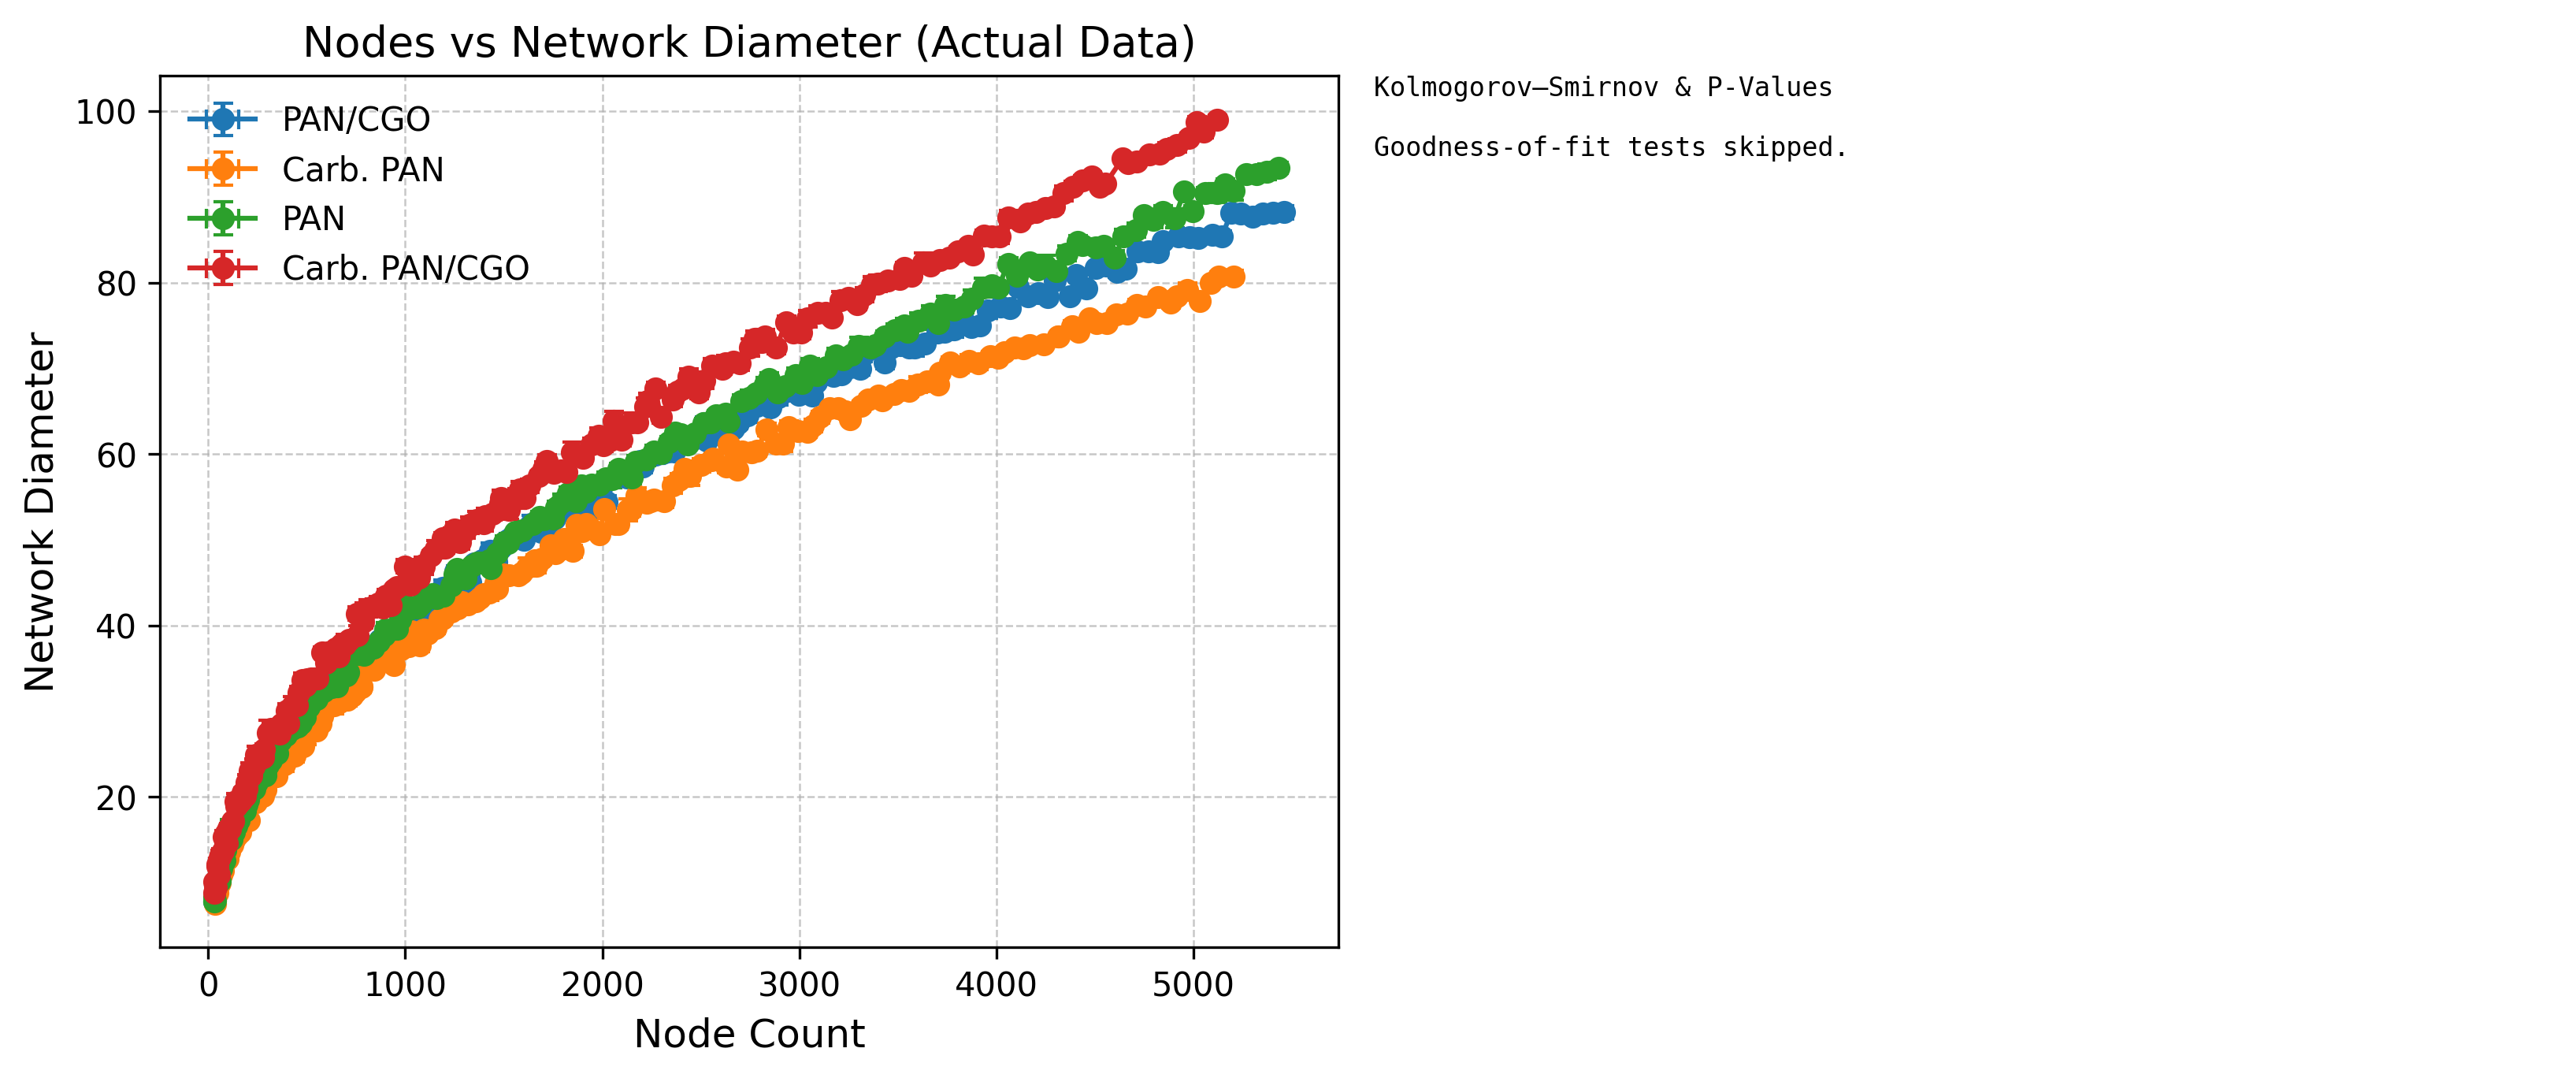

In [14]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']
plt_fig = sgt_scaling_plot("Network Diameter", df_dia, material_labels, skip_test=True)
plt_figs.append(plt_fig)

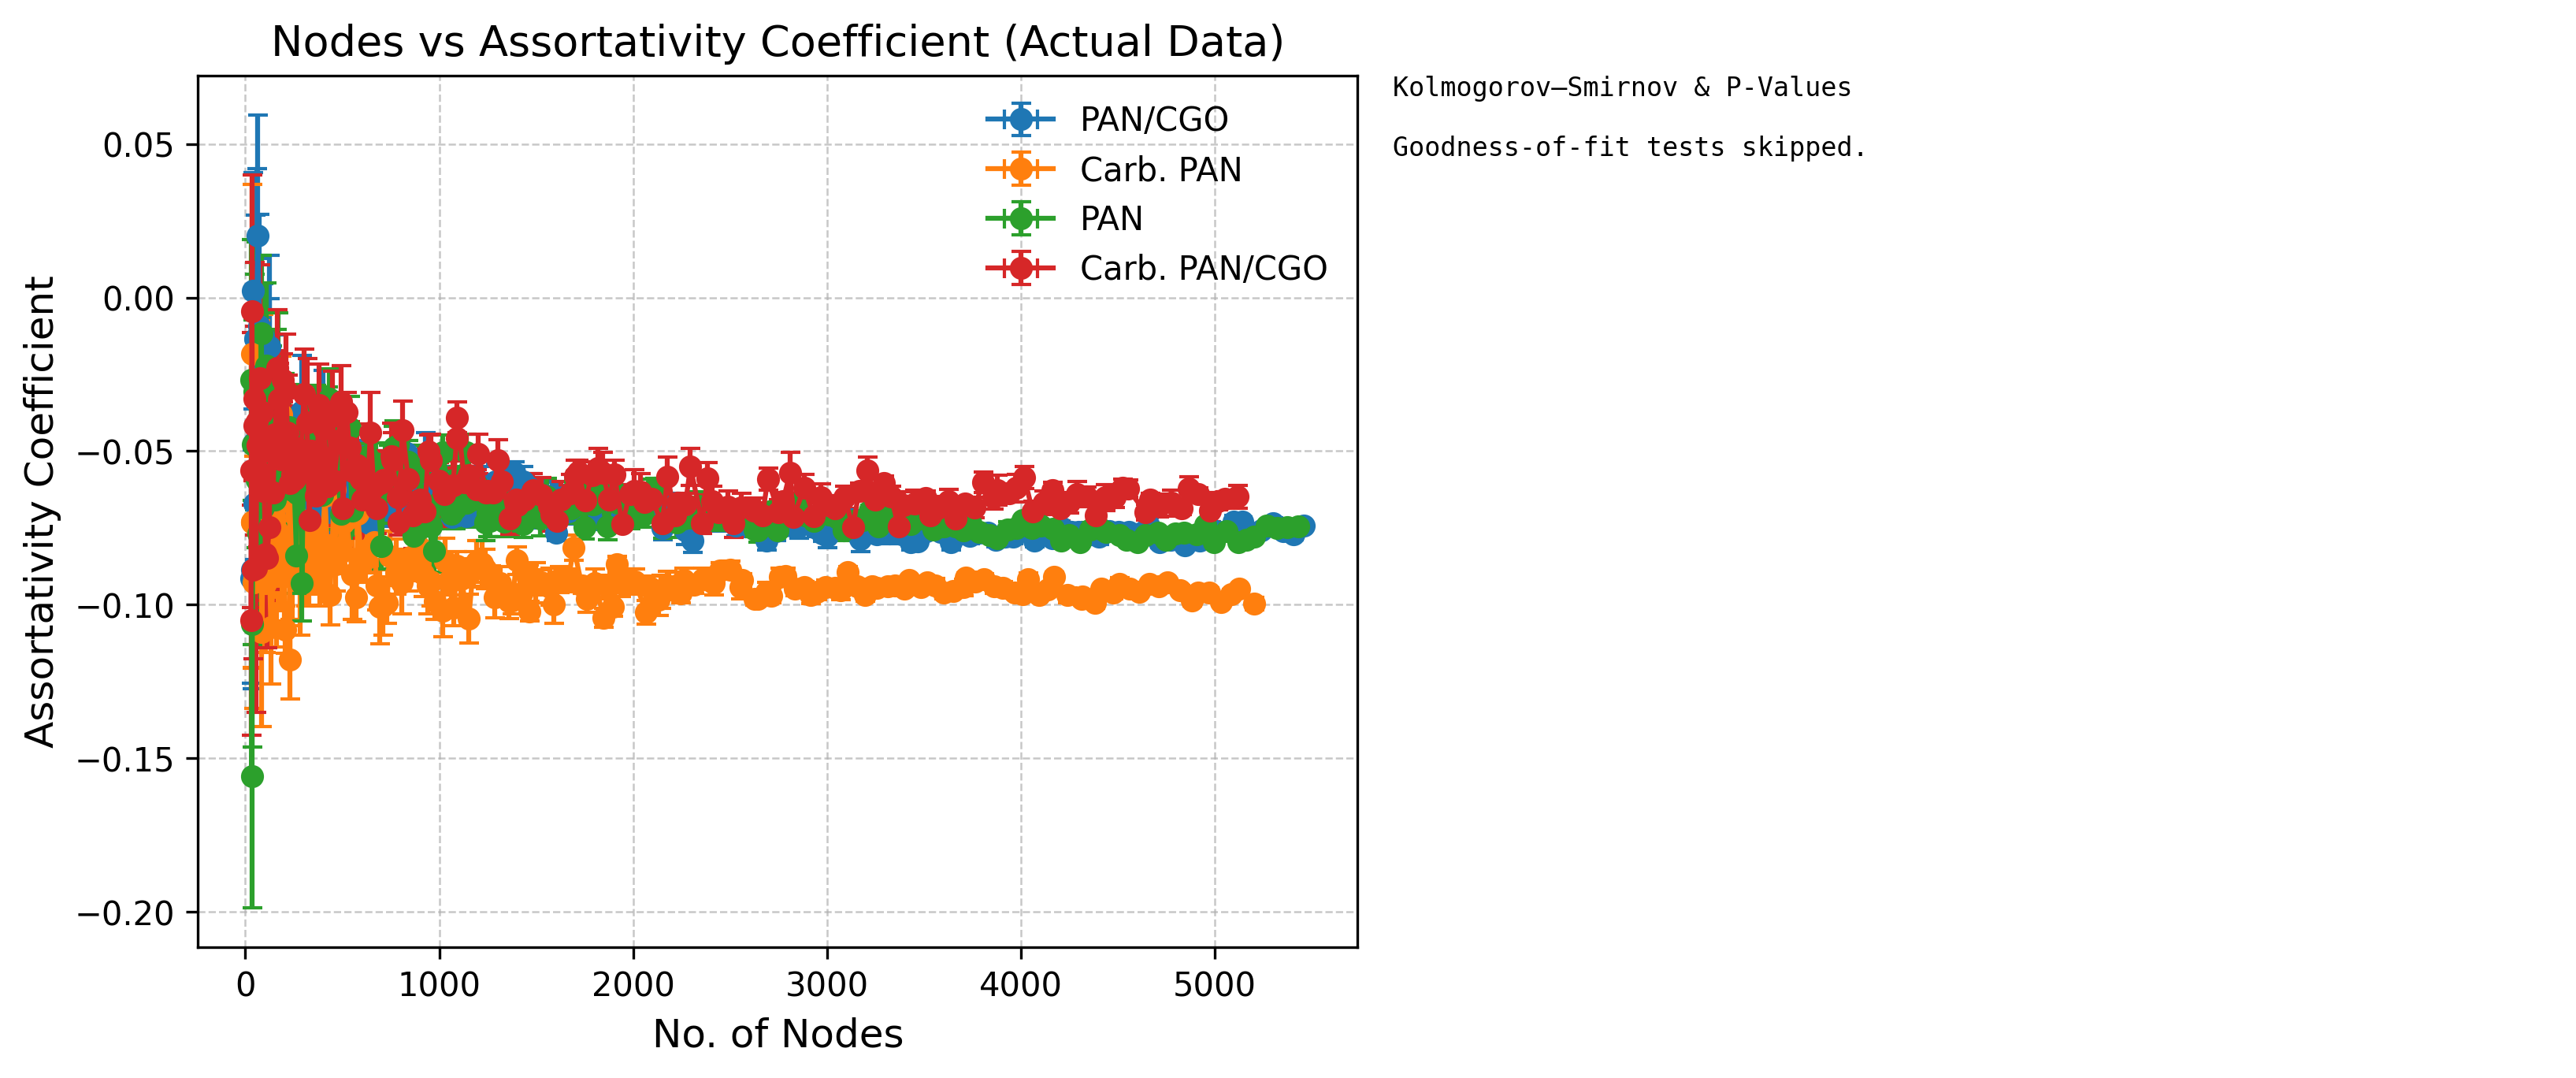

In [15]:
"""
Assortativity Coefficient
"""
df_asc = all_sheets['Nodes-ASC']
plt_fig = sgt_scaling_plot("Assortativity Coefficient", df_asc, material_labels, skip_test=True)
plt_figs.append(plt_fig)

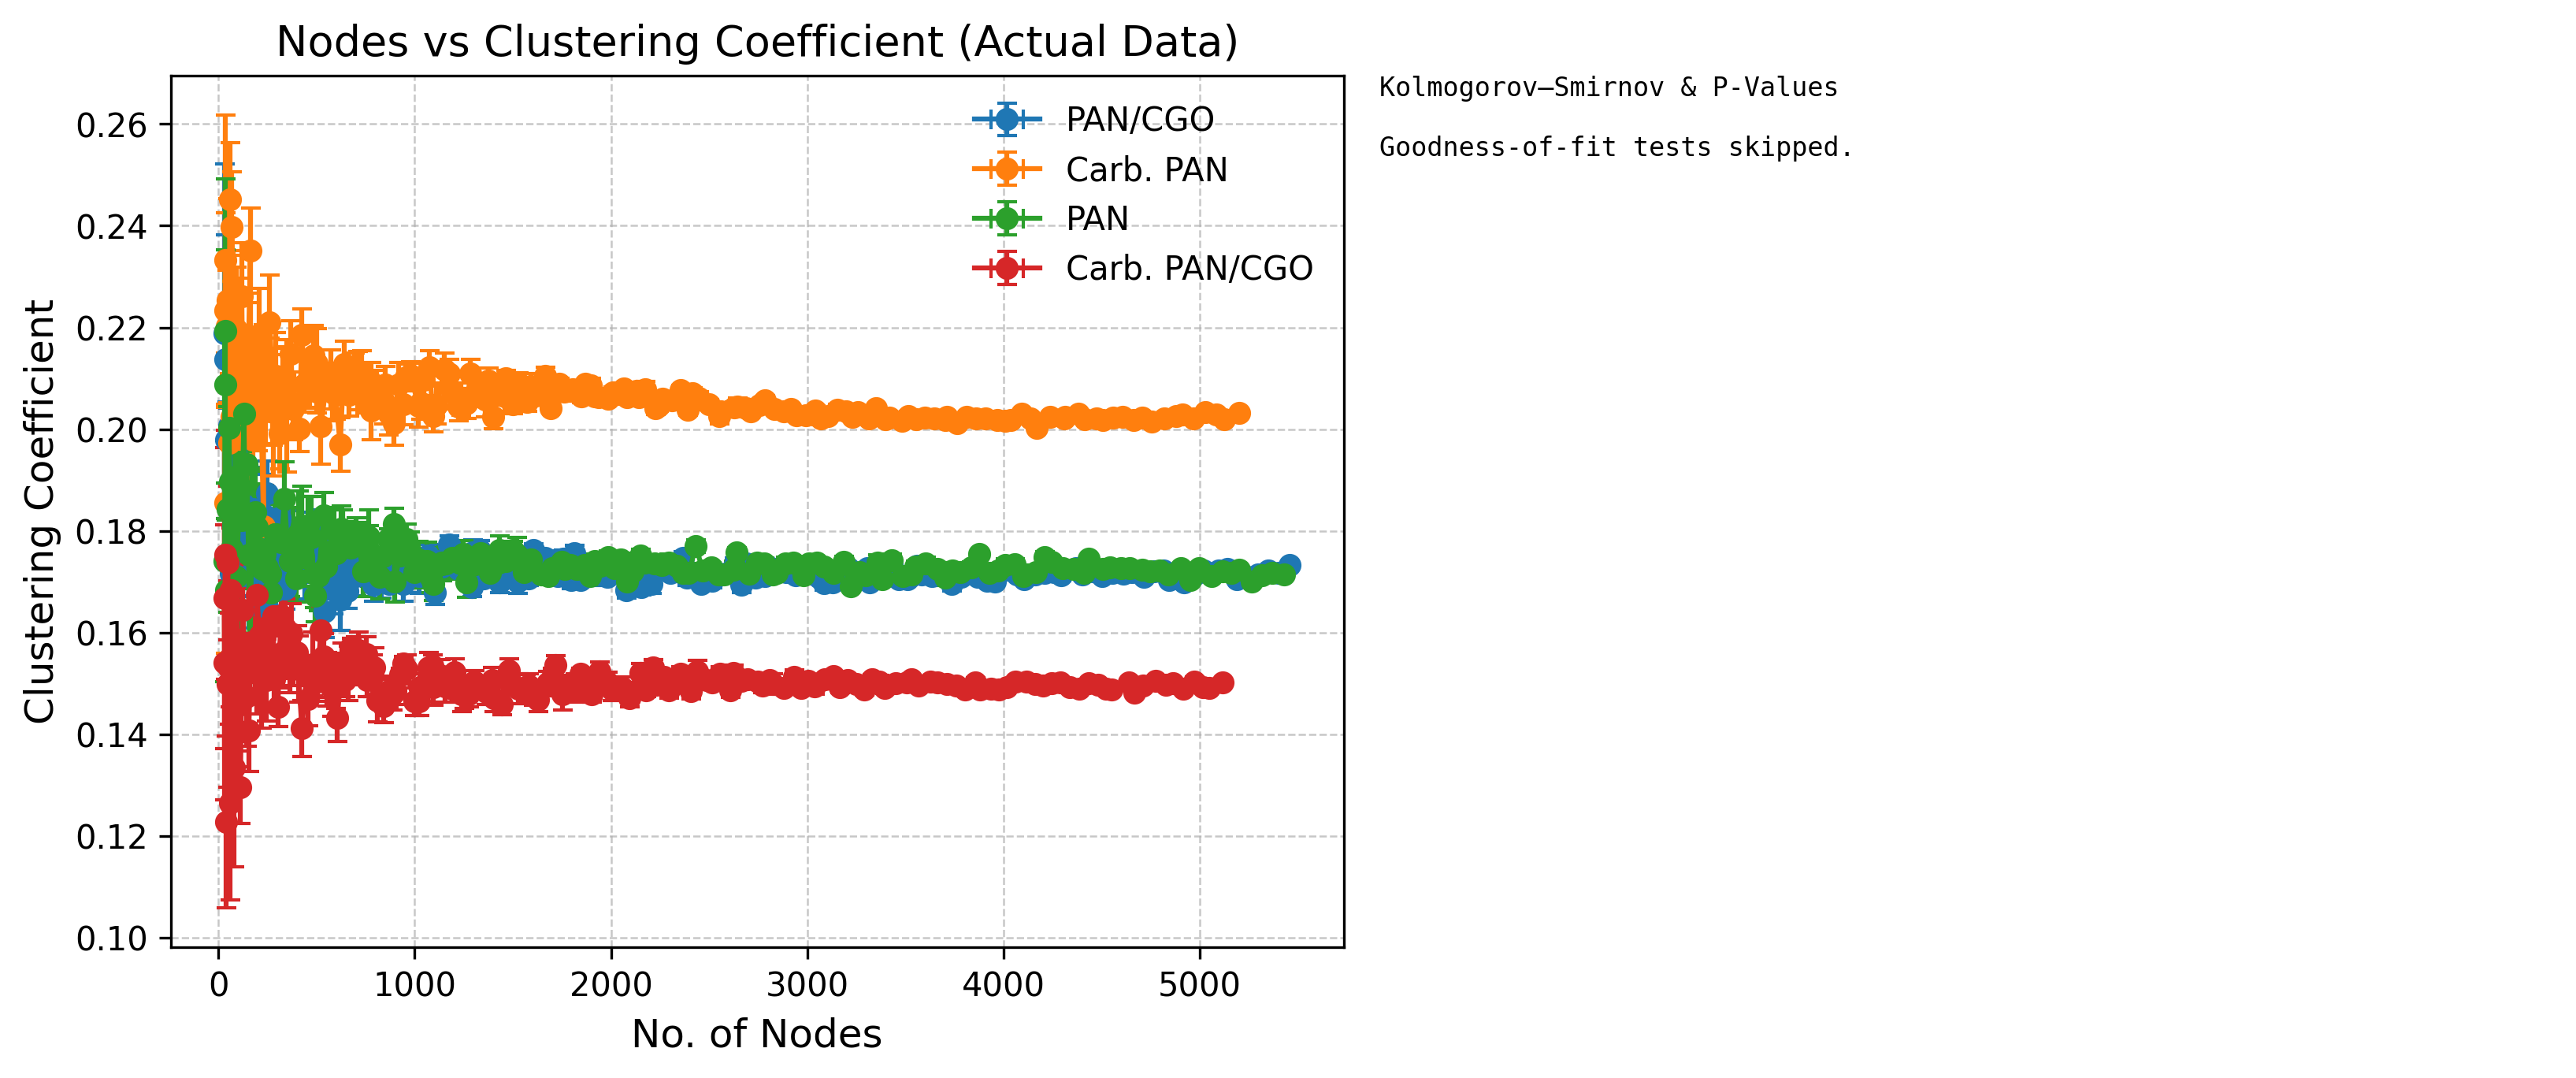

In [18]:
"""
Clustering Coefficient
"""
df_acc = all_sheets['Nodes-ACC']
plt_fig = sgt_scaling_plot("Clustering Coefficient", df_acc, material_labels, skip_test=True)
plt_figs.append(plt_fig)

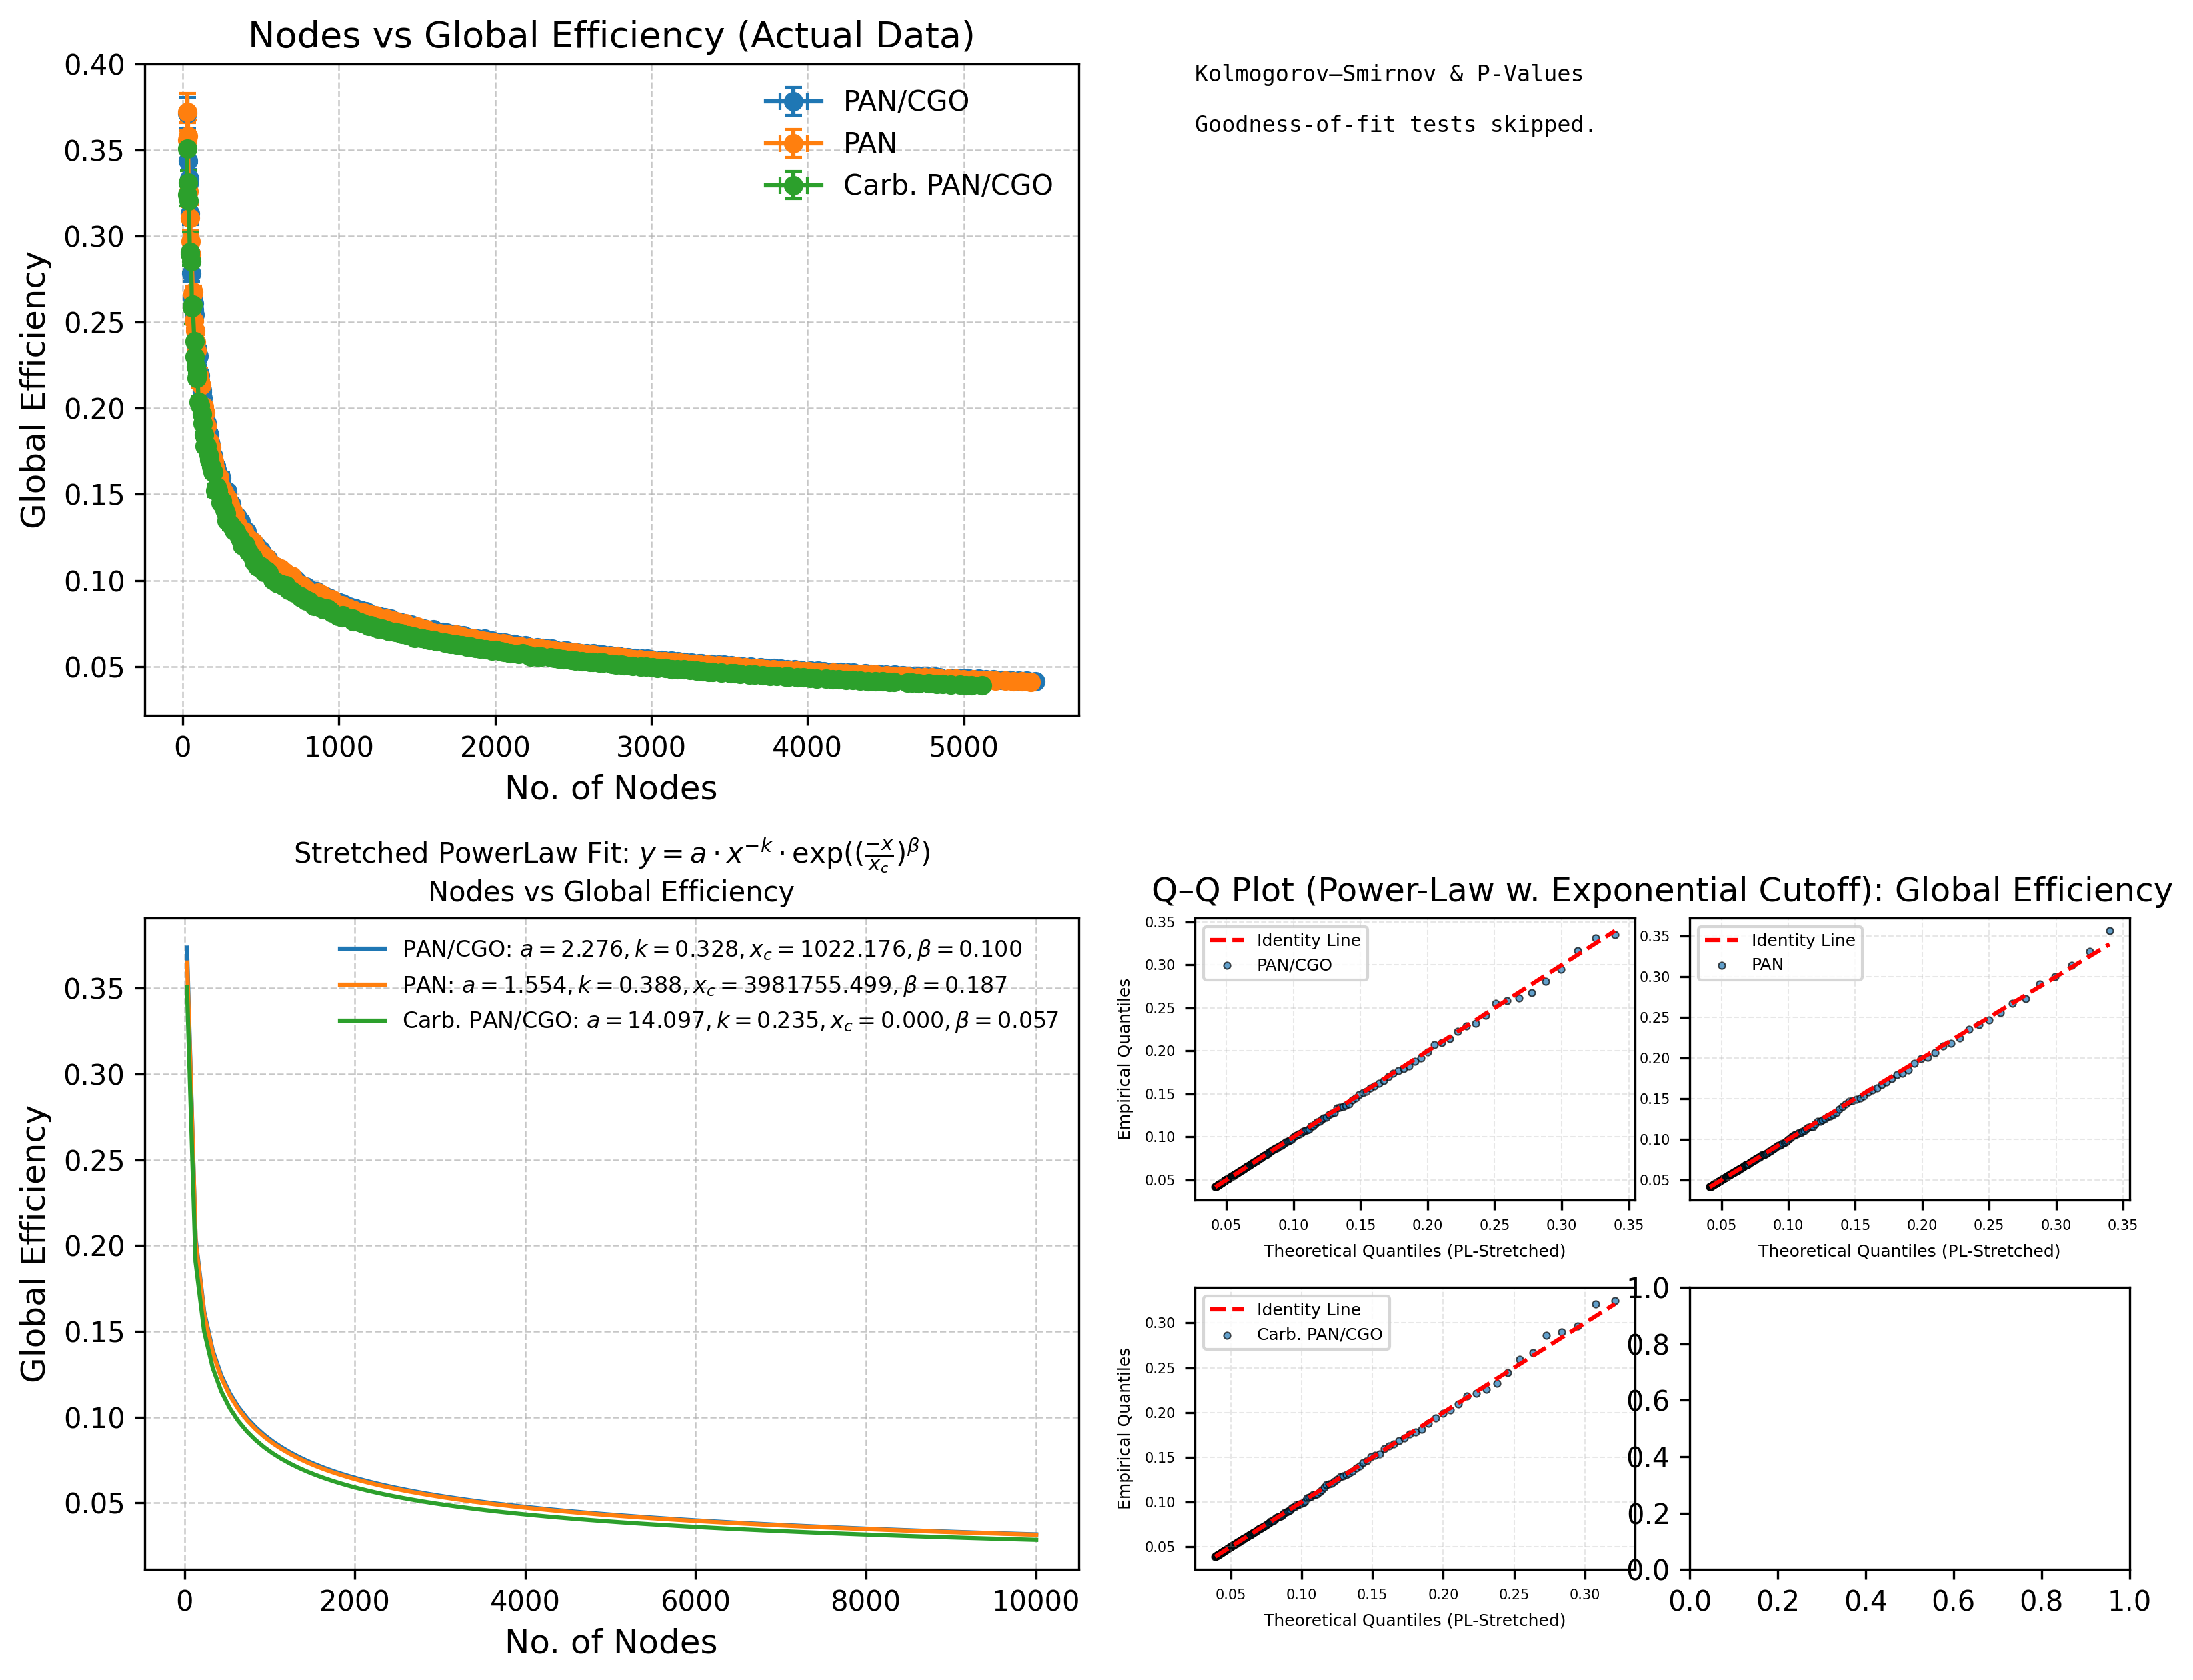

In [19]:
"""
Global Efficiency
"""
df_ge = all_sheets['Nodes-GE']
plt_fig = sgt_scaling_plot("Global Efficiency", df_ge, material_labels, skip_test=True, fit_func="powerlaw-ec")
plt_figs.append(plt_fig)

In [ ]:
with PdfPages(pdf_file) as pdf:
    for fig in plt_figs:
        pdf.savefig(fig)